PROJECT TITLE: GNSS-IMU fusion for robust walking trajectory estimation and biomarker-ready feature extraction


This project proposes a pipeline for improving smartphone based walking trajectories estimation using GNSS-IMU preprocessing and sensor fusion with the goal of producing cleaner trajectories for biomarkers analysis.

Info about the dataset: https://datadryad.org/dataset/doi%3A10.5061/dryad.n2z34tn5q?

The dataset contains walking activity including inertial and positional information from 19 volunteers, including a ground truth reference data measured using a trundle wheel. The dataset includes a total of 97.6km waled by volunteers which are split into 203 tracks. 

Each track has gyroscope and accelerometer embedded in the phones, location information from the Global Navigation Satellite System (GNSS), and the step count obtained by the device.

GOALS OF THE PROJECTS:
The goal of this project is to show the following:
1. Raw GNSS data can be noisy and irregular 

2. IMU-only dead reckoning drifts overtime 

3. Preprocessing improves signal quality 

4. GNSS-IMU fusion using EKF gives a more stable trajectory estimates 

5. Cleaner trajectores can support bio-marker analysis.

Phase 1: Understanding the data:

In this phase we want to understand the dataset and answer the following questions: 

1. How many tracks have GNSS?

2. How many tracks have IMU/motion?

3. How many tracks have both GNSS and IMU?

4. Which tracks have the least GNSS and IMU gaps?

5. Which tracks have continuous reference distance?

6. Which track should you select for your first experiment?



In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from filterpy.kalman import KalmanFilter

In [2]:
df=pd.read_csv("Data-IMU-GNSS/data/metadata_tracks.csv")
has_gns_imu=df[(df['hasMotion']==True) & (df['hasGNSS']==True) & (df['total_gaps_time_inertial']<5) & (df['total_gaps_time_gnss']<10)]
has_gns_imu.head()

,subject,testID,testName,isPatient,distanceReference,hasMotion,hasGNSS,device,distanceByApp,totSteps,...,gt_type,country,gnss_anonimized,duration [s],fs_acc,fs_gnss,fs_steps,average_walking_speed,smartphone_position,smartphone app
38,3,3,3_3,True,527,True,True,OnePlus KB2003,538.652157,656.0,...,final,UK,True,361,59.670360,1.573407,1.770083,1.459834,hand held,Timed Walk
39,3,4,3_4,True,561,True,True,OnePlus KB2003,574.514709,682.0,...,final,UK,True,364,59.255495,1.019231,1.857143,1.541209,hand held,Timed Walk
45,4,0,4_0,True,486,True,True,samsung SM-G986B,493.970449,637.0,...,final,UK,True,383,55.707572,1.566580,1.639687,1.268930,hand held,Timed Walk
46,4,1,4_1,True,474,True,True,samsung SM-G986B,478.094434,622.0,...,final,UK,True,385,56.101299,1.561039,1.612987,1.231169,hand held,Timed Walk
47,4,2,4_2,True,447,True,True,samsung SM-G986B,447.402597,617.0,...,final,UK,True,363,59.363636,1.666667,1.699725,1.231405,hand held,Timed Walk


The above filter selects the tracks which has both GNSS and IMU data aviavible. This is necessary as our study wants both the signals to be present. Also an addational filter is been applied such that time interval between the signal loss of IMU is less than 5s and GNSS is less than 10s. 
This is an initial filter for selection of tracks more indepth filter will be applied before selecting the final list of qualified tracks. 

gt_type=continous
gt_type tells us what kind of refrence distance is present. There are 2 values of gt_type which has continous and final. Final value contains only the final refrence distance while continous contains the signals over the perioud of time.

In [3]:
has_gns_imu_continuous = has_gns_imu[
    (has_gns_imu["gt_type"] == "continuous") &
    (has_gns_imu["distanceReference"] != 0)
]
has_gns_imu_continuous.head()

,subject,testID,testName,isPatient,distanceReference,hasMotion,hasGNSS,device,distanceByApp,totSteps,...,gt_type,country,gnss_anonimized,duration [s],fs_acc,fs_gnss,fs_steps,average_walking_speed,smartphone_position,smartphone app
168,14,0,14_0,False,1000,True,True,Xiaomi Redmi Note 9 Pro,1035.164078,1366.0,...,continuous,SE,False,873,59.980527,1.002291,1.565865,1.145475,hand held,Malisa
169,14,1,14_1,False,1005,True,True,Xiaomi Redmi Note 9 Pro,987.643819,1254.0,...,continuous,SE,False,761,59.939553,1.005256,1.649146,1.320631,hand held,Malisa
170,14,2,14_2,False,1001,True,True,Xiaomi Redmi Note 9 Pro,1002.676164,1272.0,...,continuous,SE,False,774,59.979328,1.003876,1.644703,1.293282,hand held,Malisa
171,14,3,14_3,False,1011,True,True,Xiaomi Redmi Note 9 Pro,1011.892553,1165.0,...,continuous,SE,False,665,59.939850,1.004511,1.753383,1.520301,hand held,Malisa
172,14,4,14_4,False,1002,True,True,Xiaomi Redmi Note 9 Pro,1042.694672,1068.0,...,continuous,SE,False,582,59.915808,1.001718,1.838488,1.721649,hand held,Malisa


After the filtering there are 5 stacks which set out creteria. Subject no 14 and track no 0,1,2,3,4 are the tracks which has GNSS, IMU data gt_type is continous and the distanceReference is not null. 


Phase 2 Track Selection:

As a primary selection creteria we have 5 tracks for suject no 14. Now we want to rank all the tracks and select one track from them for an indepth analysis. 
Considerations for Ideal tack:
1. total_gaps_time_inertial 
2. total_gaps_time_nss
3. distanceReference vs distanceByApp
4. average walking speed 
5. path curvature 
6. duration





In track selection we want to select a track with minimal difference between the reference distance and the measured distance. This track will be a good baseline initially and then we can move to tracks which have a large distance in reference distance and measured distance. 

In [102]:
test_subs = ["14_0", "14_1", "14_2", "14_3", "14_4"]

selected_tracks = has_gns_imu_continuous.loc[
    has_gns_imu_continuous["testName"].isin(test_subs)
].copy()

selected_tracks["distance_error_app"] = (
    selected_tracks["distanceByApp"] - selected_tracks["distanceReference"]
).abs()

sorting = [
    "total_gaps_time_inertial",
    "total_gaps_time_gnss",
    "distance_error_app",
    "average_walking_speed"
]

selected_tracks_sorted = selected_tracks.sort_values(by=sorting)

selected_tracks_sorted[
    [
        "subject",
        "testID",
        "testName",
        "distanceReference",
        "distanceByApp",
        "distance_error_app",
        "total_gaps_time_inertial",
        "total_gaps_time_gnss",
        "average_walking_speed",
        "gt_type",
    ]
]

,subject,testID,testName,distanceReference,distanceByApp,distance_error_app,total_gaps_time_inertial,total_gaps_time_gnss,average_walking_speed,gt_type
171,14,3,14_3,1011,1011.892553,0.892553,0.0,0.0,1.520301,continuous
170,14,2,14_2,1001,1002.676164,1.676164,0.0,0.0,1.293282,continuous
169,14,1,14_1,1005,987.643819,17.356181,0.0,0.0,1.320631,continuous
168,14,0,14_0,1000,1035.164078,35.164078,0.0,0.0,1.145475,continuous
172,14,4,14_4,1002,1042.694672,40.694672,0.0,0.0,1.721649,continuous


For this filter we have filterted tracks which have a abs difference between refrence and measured values of less than 50m.

After applying the track-selection criteria, three tracks from Subject 14 satisfied the requirements: 14_3, 14_2, 14_1, 14_0 and 14_4. All three contain GNSS and IMU data, continuous reference distance, low sensor gaps, and realistic walking speeds.

Track 14_3 was selected as the main development track because it has the lowest app-reference distance error of 0.89 m, a normal walking speed of 1.52 m/s, and stable GNSS/IMU sampling frequencies. This makes it suitable for building and validating the initial preprocessing and trajectory estimation pipeline.

Tracks 14_0 and 14_4 will be used later as validation or challenge tracks because they have larger app-reference distance errors, allowing evaluation of whether the GNSS–IMU fusion pipeline improves trajectory consistency.

Phase 3: Raw Data Exploration. 

Understanding the events.csv, positions.csv, orientation.csv, steps.csv, motion.csv,reference_cont_distance.csv files associated with the 14_3 track. 

events.csv: Time at which the test starts but not walking(GNSS)

positions.csv: GNSS speen and heading after 0ms

orientation.csv: Phone orientation

steps.csv: Number in incremental steps taken

motion.csv: IMU signals. With and without gravity

reference_cont_distance.csv: Ground distance 


3.1 Understanding events.csv 


In [7]:
df_events=pd.read_csv("Data-IMU-GNSS/data/subject_14/14_3/events.csv")
df_position=pd.read_csv("Data-IMU-GNSS/data/subject_14/14_3/positions.csv")
df_motion=pd.read_csv("Data-IMU-GNSS/data/subject_14/14_3/motion.csv")
df_orientation=pd.read_csv("Data-IMU-GNSS/data/subject_14/14_3/orientation.csv")
df_steps=pd.read_csv("Data-IMU-GNSS/data/subject_14/14_3/steps.csv")
df_ref_cont_dist=pd.read_csv("Data-IMU-GNSS/data/subject_14/14_3/reference_cont_distance.csv")

In [8]:
time_duration_events = (df_events["testEnd"].iloc[0] - df_events["testStart"].iloc[0]) / 1000

time_duration_meta = df.loc[df["testName"] == "14_3", "duration [s]"].iloc[0]

duration_difference = abs(time_duration_meta - time_duration_events)

print("Signal Start:",df_events['signalStart'].iloc[0])
print("Start time:",df_events['testStart'].iloc[0]/1000)
print("Start time:",df_events['testEnd'].iloc[0]/1000)
print("Events duration:", time_duration_events)
print("Metadata duration:", time_duration_meta)
print("Difference:", duration_difference)

Signal Start: 0
Start time: 4.039
Start time: 665.3329999446869
Events duration: 661.2939999446869
Metadata duration: 665
Difference: 3.7060000553130976


The events duration is 661.3s while the metadata duration is around 665s. The difference between metadata and the events is around 3.7s which is sufficient for out analysis.
The next step is deciding wheather position, motion, orientation, steps and reference_cont_distance also are in the same duration. This will effect our fusion process in the EKF later.

Position Time coverage

In [9]:
print("events testStart:", df_events["testStart"].iloc[0])
print("positions first ms:", df_position["ms"].iloc[0])
print("positions last ms:", df_position["ms"].iloc[-1])
print("events testEnd:", df_events["testEnd"].iloc[0])

"""The events testStart, testEnd is close to the position first signal and signal end indicating that position covers the full range of duration"""

events testStart: 4039.0
positions first ms: 4039.0
positions last ms: 667039.0
events testEnd: 665332.9999446869


'The events testStart, testEnd is close to the position first signal and signal end indicating that position covers the full range of duration'

Motion Time Coverage

In [10]:
df_motion.columns
df_motion.head()

,Unnamed: 0,ms,accelX,accelY,accelZ,accelWithGX,accelWithGY,accelWithGZ,rotRateAlpha,rotRateBeta,rotRateGamma,interval
0,0,159.0,0.0,0.0,-0.9,-1.1,1.3,9.4,14.9,-1.2,-1.2,16
1,1,175.0,0.5,-0.1,-1.0,-0.7,1.3,9.3,18.5,-8.2,2.0,16
2,2,194.0,0.6,-0.1,-0.9,-0.7,1.3,9.3,14.1,-15.4,1.4,16
3,3,209.0,0.8,-0.1,0.1,-0.4,1.3,9.9,8.2,-19.3,-1.5,16
4,4,225.0,0.7,-0.4,0.7,-0.2,0.9,11.0,3.2,-17.2,-4.4,16


In [11]:
print("events testStart:", df_events["testStart"].iloc[0])
print("motion first ms:", df_motion["ms"].iloc[0])
print("motion last ms:", df_motion["ms"].iloc[-1])
print("events testEnd:", df_events["testEnd"].iloc[0])

events testStart: 4039.0
motion first ms: 159.0
motion last ms: 665299.0
events testEnd: 665332.9999446869


The IMU sensor starts collecting data before the official test time which is not a problem in itself. However we need to trim the data such that the walking window is from the official test time and the offical end time. 

Orientation Time coverage

In [12]:
df_orientation.columns
df_orientation.head()

,Unnamed: 0,ms,abs,alpha,beta,gamma
0,0,162.0,False,88.6,7.2,8.0
1,1,176.0,False,88.6,7.5,7.8
2,2,194.0,False,88.7,7.8,7.0
3,3,209.0,False,88.8,7.9,5.9
4,4,226.0,False,88.8,7.6,4.9


In [13]:
print("events testStart:", df_events["testStart"].iloc[0])
print("orientation first ms:", df_orientation["ms"].iloc[0])
print("orientation last ms:", df_orientation["ms"].iloc[-1])
print("events testEnd:", df_events["testEnd"].iloc[0])

events testStart: 4039.0
orientation first ms: 162.0
orientation last ms: 665299.0
events testEnd: 665332.9999446869


The orientation sensor starts collecting data before the official test time which is not a problem in itself. However we need to trim the data such that the walking window is from the official test time and the offical end time. 

Reference_cont_distance Time Coverage

In [14]:
df_ref_cont_dist.columns
df_ref_cont_dist.head()

,Unnamed: 0,ms,distance
0,0,968.0,1.0
1,1,1707.0,2.0
2,2,2470.0,3.0
3,3,3236.0,4.0
4,4,3911.0,5.0


In [15]:
print("events testStart:", df_events["testStart"].iloc[0])
print("orientation first ms:", df_ref_cont_dist["ms"].iloc[0])
print("orientation last ms:", df_ref_cont_dist["ms"].iloc[-1])
print("events testEnd:", df_events["testEnd"].iloc[0])

events testStart: 4039.0
orientation first ms: 968.0
orientation last ms: 665210.0
events testEnd: 665332.9999446869


The refrence_cont_distance sensor starts collecting data before the official test time which is not a problem in itself. However we need to trim the data such that the walking window is from the official test time and the offical end time. 

In [16]:
test_start = df_events["testStart"].iloc[0]
test_end = df_events["testEnd"].iloc[0]

coverage_rows = [
    {
        "file": "positions",
        "first_ms": df_position["ms"].iloc[0],
        "last_ms": df_position["ms"].iloc[-1],
    },
    {
        "file": "motion",
        "first_ms": df_motion["ms"].iloc[0],
        "last_ms": df_motion["ms"].iloc[-1],
    },
    {
        "file": "orientation",
        "first_ms": df_orientation["ms"].iloc[0],
        "last_ms": df_orientation["ms"].iloc[-1],
    },
    {
        "file": "reference_cont_distance",
        "first_ms": df_ref_cont_dist["ms"].iloc[0],
        "last_ms": df_ref_cont_dist["ms"].iloc[-1],
    },
]

test_start = df_events["testStart"].iloc[0]
test_end = df_events["testEnd"].iloc[0]

coverage_rows = [
    {
        "file": "positions",
        "first_ms": df_position["ms"].iloc[0],
        "last_ms": df_position["ms"].iloc[-1],
    },
    {
        "file": "motion",
        "first_ms": df_motion["ms"].iloc[0],
        "last_ms": df_motion["ms"].iloc[-1],
    },
    {
        "file": "orientation",
        "first_ms": df_orientation["ms"].iloc[0],
        "last_ms": df_orientation["ms"].iloc[-1],
    },
    {
        "file": "reference_cont_distance",
        "first_ms": df_ref_cont_dist["ms"].iloc[0],
        "last_ms": df_ref_cont_dist["ms"].iloc[-1],
    },
]

In [17]:
coverage_table = pd.DataFrame(coverage_rows)

coverage_table["duration_s"] = (
    coverage_table["last_ms"] - coverage_table["first_ms"]
) / 1000

coverage_table["starts_before_testStart_s"] = (
    test_start - coverage_table["first_ms"]
) / 1000

coverage_table["ends_after_testEnd_s"] = (
    coverage_table["last_ms"] - test_end
) / 1000

coverage_table["covers_test_window"] = (
    (coverage_table["first_ms"] <= test_start) &
    (coverage_table["last_ms"] >= test_end)
)

coverage_table

,file,first_ms,last_ms,duration_s,starts_before_testStart_s,ends_after_testEnd_s,covers_test_window
0,positions,4039.0,667039.0,663.000,0.000,1.706,True
1,motion,159.0,665299.0,665.140,3.880,-0.034,False
2,orientation,162.0,665299.0,665.137,3.877,-0.034,False
3,reference_cont_distance,968.0,665210.0,664.242,3.071,-0.123,False


The time coverage table shows that positions.csv covers the complete official test window. Motion, orientation, and reference continuous distance start before the official testStart and end very close to testEnd. This means the main sensor streams cover the walking interval sufficiently. In the preprocessing phase, all streams should be trimmed to the official testStart–testEnd window.

In [18]:
df_position.head()

,Unnamed: 0,ms,latitude,longitude,altitude,confInterval,heading,speed
0,0,4039.0,55.608629,13.004264,41.876038,7.572926,161.600006,1.45
1,1,5039.0,55.608620,13.004240,43.179199,6.511917,173.500000,1.27
2,2,6039.0,55.608597,13.004232,44.870728,4.907988,178.100006,1.37
3,3,5004.0,55.608201,13.004540,40.500000,28.943001,NaN,NaN
4,4,5009.0,55.608201,13.004540,40.500000,28.943001,NaN,NaN


3.2) Explore Raw GNSS Data — positions.csv

In [19]:
summary_stats_position = pd.DataFrame([
    {
        "file": "positions.csv",
        "num_samples": len(df_position),

        "first_ms": df_position["ms"].iloc[0],
        "last_ms": df_position["ms"].iloc[-1],
        "duration_s": (df_position["ms"].iloc[-1] - df_position["ms"].iloc[0]) / 1000,

        "missing_ms": df_position["ms"].isna().sum(),
        "missing_latitude": df_position["latitude"].isna().sum(),
        "missing_longitude": df_position["longitude"].isna().sum(),
        "missing_altitude": df_position["altitude"].isna().sum(),
        "missing_confInterval": df_position["confInterval"].isna().sum(),
        "missing_heading": df_position["heading"].isna().sum(),
        "missing_speed": df_position["speed"].isna().sum(),

        "min_speed": df_position["speed"].min(),
        "max_speed": df_position["speed"].max(),
        "mean_speed": df_position["speed"].mean(),

        "min_confInterval": df_position["confInterval"].min(),
        "max_confInterval": df_position["confInterval"].max(),
        "mean_confInterval": df_position["confInterval"].mean(),
    }
])

summary_stats_position

,file,num_samples,first_ms,last_ms,duration_s,missing_ms,missing_latitude,missing_longitude,missing_altitude,missing_confInterval,missing_heading,missing_speed,min_speed,max_speed,mean_speed,min_confInterval,max_confInterval,mean_confInterval
0,positions.csv,668,4039.0,667039.0,663.0,0,0,0,0,0,4,4,1.04,3.13,1.458178,3.790092,28.943001,3.991599


1. GNSS trajectory plot

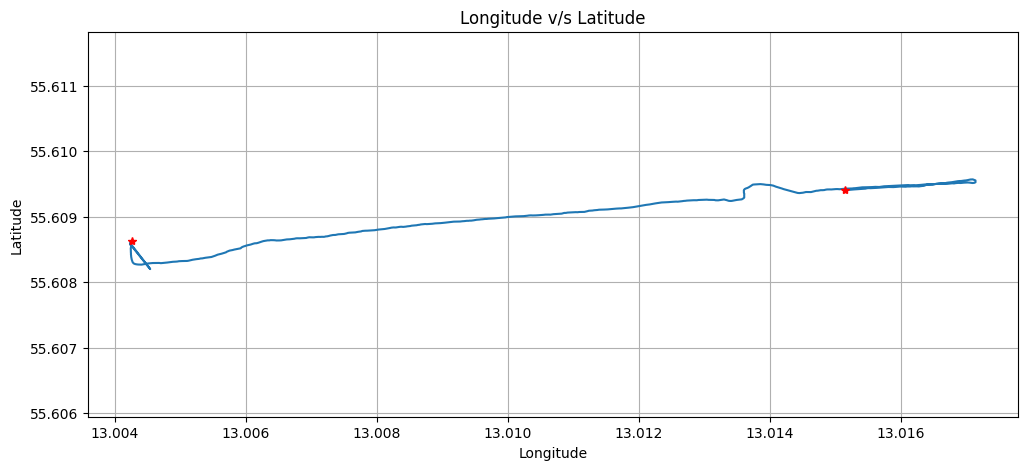

In [20]:
x_vals=df_position['longitude'].values
y_vals=df_position['latitude'].values

plt.figure(figsize=(12,5))

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid()
plt.axis("equal")
plt.title('Longitude v/s Latitude')

plt.plot(x_vals,y_vals, marker='*',markevery=[0,-1], markerfacecolor='red', markeredgecolor='red')
plt.show()

This plot suggets that the raw GNSS data is mostly continous with a clear walking path with starting point and the end point, but there are 2 visible fluctuation:
1. At the start 
2. At Longitude ~ 13.014

These fluctuations must be check against speed, confidence intevral, heading and gyroscope data to check if these are real turns or sensor errors



2. GNSS speed vs time

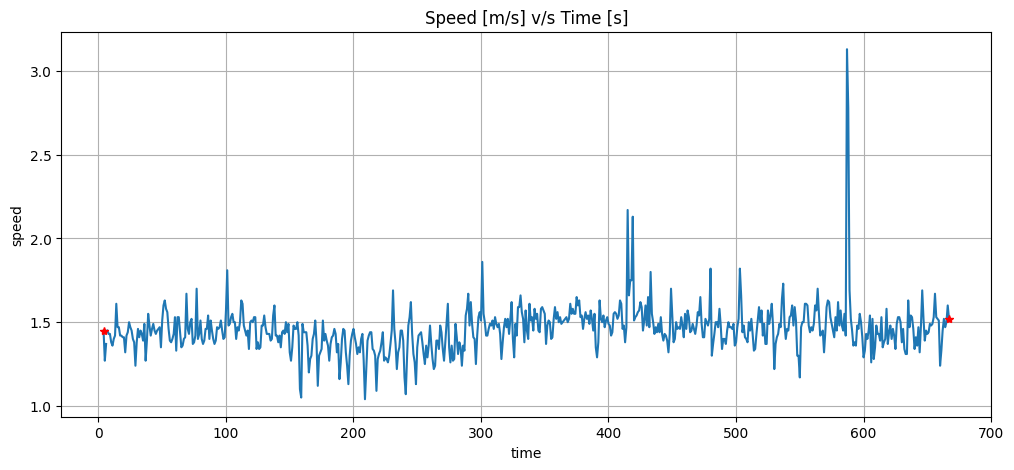

In [21]:
x_vals=df_position['ms'].values / 1000
y_vals=df_position['speed'].values
plt.figure(figsize=(12,5))
plt.xlabel('time')
plt.ylabel('speed')
plt.grid()

plt.title('Speed [m/s] v/s Time [s]')

plt.plot(x_vals,y_vals, marker='*',markevery=[0,-1], markerfacecolor='red', markeredgecolor='red' )
plt.show()

This plot shows a moderate walking speed of 1.3m/s - 1.8m/s. However there are two sudden jumps of speed at time 410s and at 590s. The walking speed at those instances are incredibly high. This needs to be verified with the heading, gyroscope data if its a sharp bend or sensor error

3. GNSS heading vs time.

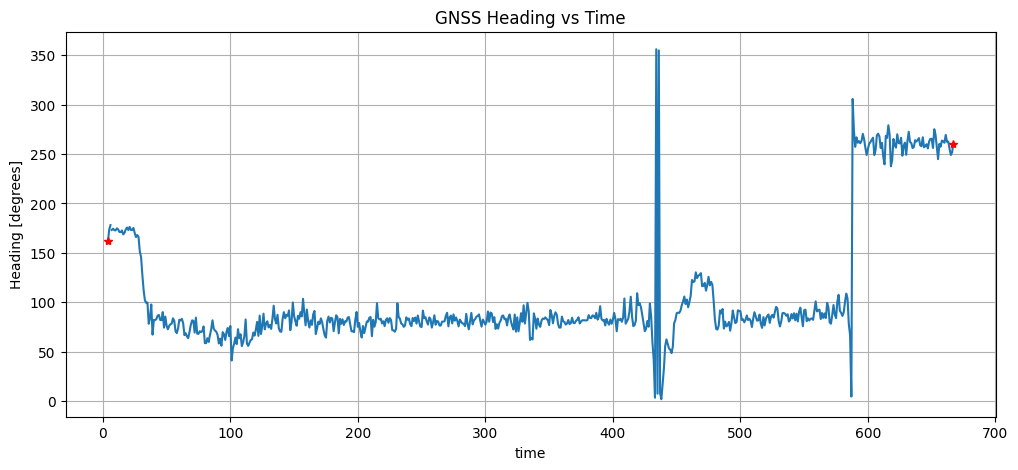

In [22]:
x_vals=df_position['ms'].values / 1000
y_vals=df_position['heading'].values

plt.figure(figsize=(12,5))
plt.xlabel('time')
plt.ylabel("Heading [degrees]")
plt.grid()

plt.title("GNSS Heading vs Time")

plt.plot(x_vals,y_vals, marker='*',markevery=[0,-1], markerfacecolor='red', markeredgecolor='red' )
plt.show()

This plot shows there is sharp heading change at time 410s and 590s. This could be becuase the track could be a loop. This should later be compared with the gyroscope signal and the raw trajectory.


4. GNSS confidence interval vs time

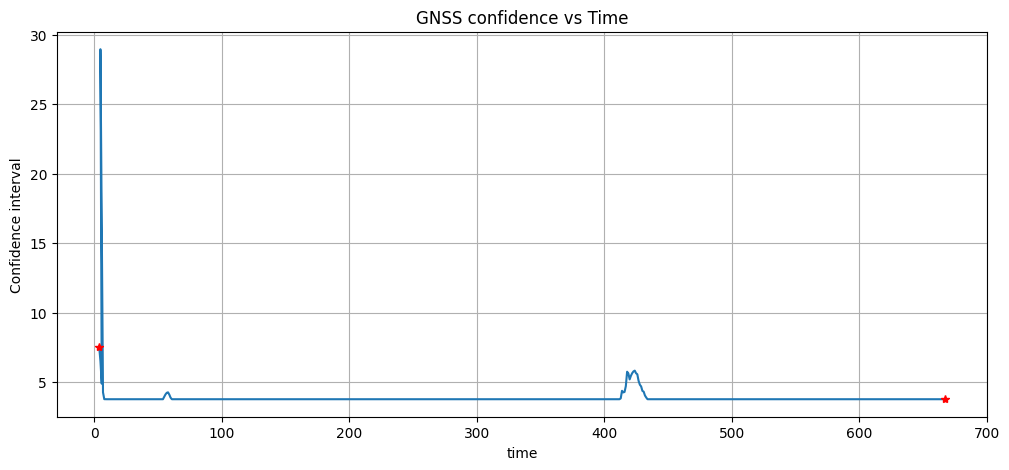

In [23]:

x_vals=df_position['ms'].values / 1000
y_vals=df_position['confInterval'].values

plt.figure(figsize=(12,5))
plt.xlabel('time')
plt.ylabel("Confidence interval")
plt.grid()

plt.title("GNSS confidence vs Time")

plt.plot(x_vals,y_vals, marker='*',markevery=[0,-1], markerfacecolor='red', markeredgecolor='red' )
plt.show()


GNSS time gap analysis: 
The time gap analysis describes if the GNSS signals were irregular/missing during the time of walking. According to the metadata, for track 14_3 the frequency is around 1Hz. That means GNSS singal should be recieved for every 1s. This time gap analysis shows that there were no missing signals. 

In [24]:
df_position["time_gap_diff"] = 0.0
for i in range(1,len(df_position)):
    df_position.loc[df_position.index[i], 'time_gap_diff']=(df_position['ms'].iloc[i] - df_position['ms'].iloc[i-1])

df_position['time_gap_diff'].head(10)

0       0.0
1    1000.0
2    1000.0
3   -1035.0
4       5.0
5       4.0
6       9.0
7    2017.0
8    1000.0
9    1000.0
Name: time_gap_diff, dtype: float64

This plot tells the GNSS uncertainty / confidence interval over time.


The GNSS confidence interval is mostly stable around 4 m, indicating generally good GNSS quality for track 14_3. However, there is a large uncertainty spike near the start of the recording and a smaller increase around 420–435 s. The second increase occurs near the same region where speed and heading changes were observed, suggesting a possible local GNSS quality issue. This region should be considered during later GNSS preprocessing and EKF measurement-noise modeling.

GNSS observation summary: 

1. The raw GNSS trajectory is mostly continuous. 
2. GNSS speed is mostly within a realistic walking range around 1.3–1.6 m/s
3. There are visible spikes, especially around 420 s and 590 s. 
4. The GNSS confidence interval is mostly stable around 4 m, but it increases near the beginning and around 420–435 s. This suggests that most of the GNSS signal is usable, but some local regions may need preprocessing or lower trust during EKF fusion.

3.3) Explore raw IMU data - motion.csv 

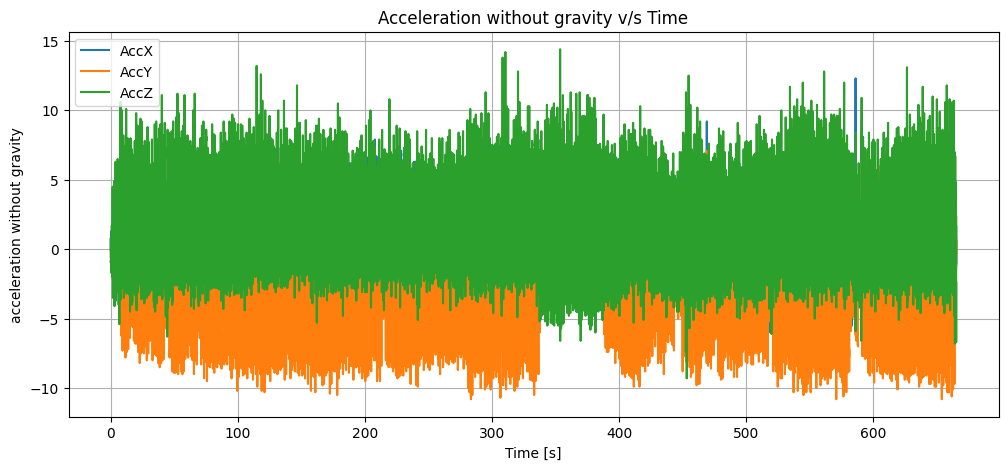

In [25]:
"""Acceleration without gravity vs Time"""

x_vals=df_motion['ms'] / 1000

plt.figure(figsize=(12,5))
plt.plot(x_vals, df_motion['accelX'].values, label='AccX')
plt.plot(x_vals, df_motion['accelY'].values, label='AccY')
plt.plot(x_vals, df_motion['accelZ'].values, label='AccZ')
plt.title('Acceleration without gravity v/s Time')
plt.xlabel('Time [s]')
plt.grid()
plt.ylabel('acceleration without gravity')
plt.legend()

plt.show()

Acceleration without gravity vs time plot: The purpose of this plot is to visualize the walking motion signal without the gravity component. 

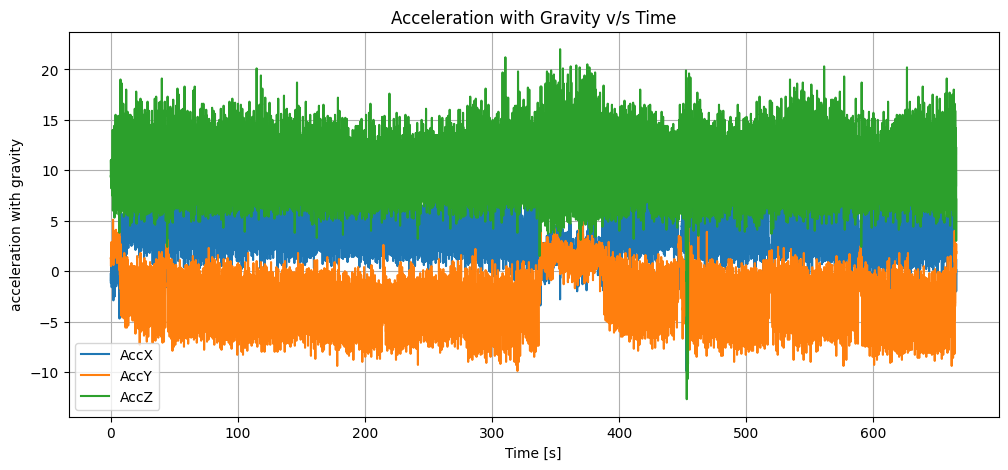

In [26]:
x_vals=df_motion['ms'] / 1000

plt.figure(figsize=(12,5))
plt.plot(x_vals, df_motion['accelWithGX'].values, label='AccX')
plt.plot(x_vals, df_motion['accelWithGY'].values, label='AccY')
plt.plot(x_vals, df_motion['accelWithGZ'].values, label='AccZ')
plt.title('Acceleration with Gravity v/s Time')
plt.xlabel('Time [s]')
plt.grid()
plt.ylabel('acceleration with gravity')
plt.legend()

plt.show()

Around 340–380 s, accelY shows a clear shift. This could indicate a temporary change in phone orientation, hand posture, walking pattern, or terrain slope. To determine whether this is human movement or a sensor/orientation effect, this segment should be compared with orientation angles, gyroscope rotation, GNSS speed, and reference distance.

Around 450 s, accelZ shows a sharp negative spike. This may indicate sudden phone movement,, a turn, or a sensor artifact. It is not possible to conclude from acceleration alone whether the participant stopped. This should be checked against acceleration magnitude, gyroscope activity, GNSS speed, and reference distance slope.

The two acceleration plots are related but not the same. The acc+gravity plots shows linear acc and gravity component this helps reveal phone orientation/gravity effects, while the acc without gravity is more usefull in understanding the linear acceleration alone. However neither can be used directly integrated without preprocessing, because hand held phones IMU data contain bias, noise and orientation effects. 

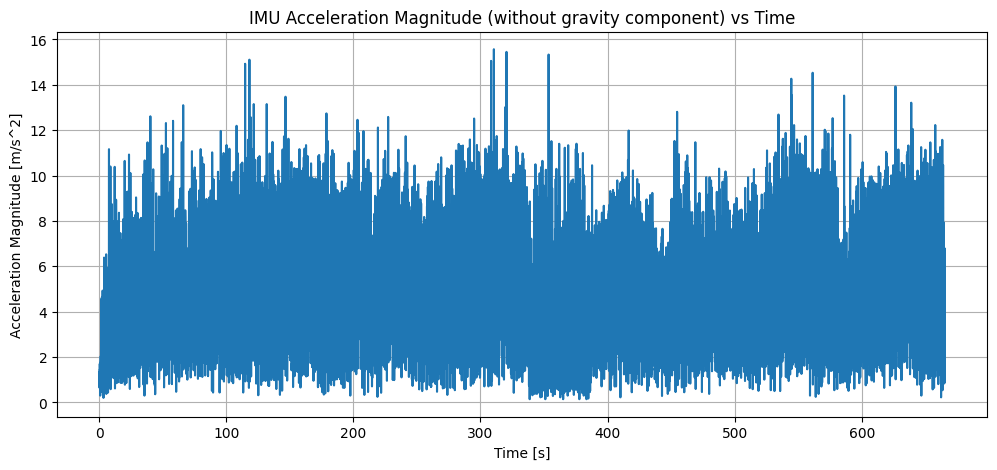

In [27]:
"""Acceleration (without gravity) magnitude vs Time plot"""

acc_mag = np.sqrt(
    df_motion["accelX"]**2 +
    df_motion["accelY"]**2 +
    df_motion["accelZ"]**2
)

time_s = df_motion["ms"] / 1000

plt.figure(figsize=(12,5))
plt.plot(time_s, acc_mag)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration Magnitude [m/s^2]")
plt.title("IMU Acceleration Magnitude (without gravity component) vs Time")
plt.grid(True)

plt.show()

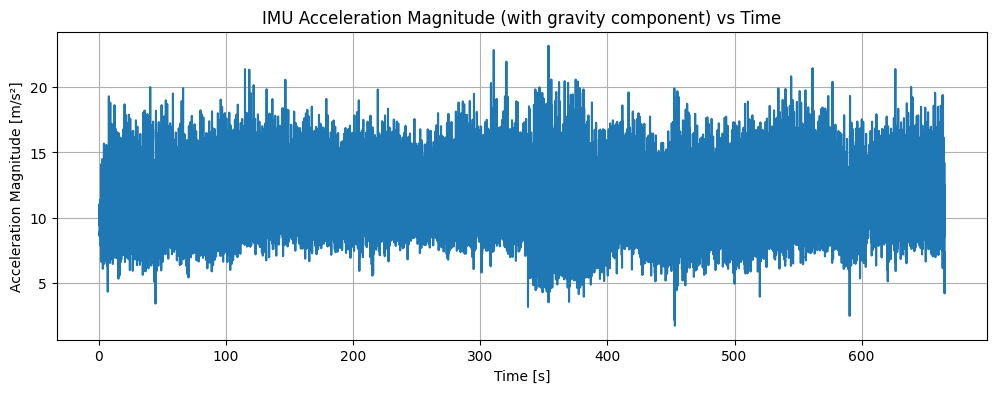

In [28]:
"""Acceleration (with gravity) magnitude vs Time plot"""
acc_mag = np.sqrt(
    df_motion["accelWithGX"]**2 +
    df_motion["accelWithGY"]**2 +
    df_motion["accelWithGZ"]**2
)

time_s = df_motion["ms"] / 1000


plt.figure(figsize=(12,4))
plt.plot(time_s, acc_mag)
plt.xlabel("Time [s]")
plt.ylabel("Acceleration Magnitude [m/s²]")
plt.title("IMU Acceleration Magnitude (with gravity component) vs Time")
plt.grid()

plt.show()

The acceleration magnitude without gravity shows continuous walking related motion throughout the track. Compared with the gravity included magnitude, this signal is more focused on dynamic movement intensity. Several regions show increased variability or spikes, especially around 300–360 s, 450 s, and 540–590 s. These regions may correspond to changes in walking dynamics, phone handling, turns, or sensor artifacts. They should be compared with gyroscope, orientation, GNSS speed, heading, and reference distance before drawing conclusions.

Important Interpations:
There are specific regions where motion behaviour changes, but acceleration along is not enoigh to saw wheather these regios are sensor artificates or real human behavior. 

3.4 IMU-data Gyroscope / rotation rate:
plotting rotRateAlpha, rotRateBeta, rotRateGamma vs time to understand the acceleration at specific time is due to sensor artificates or human causes. Also to inspect phone turns and orientation

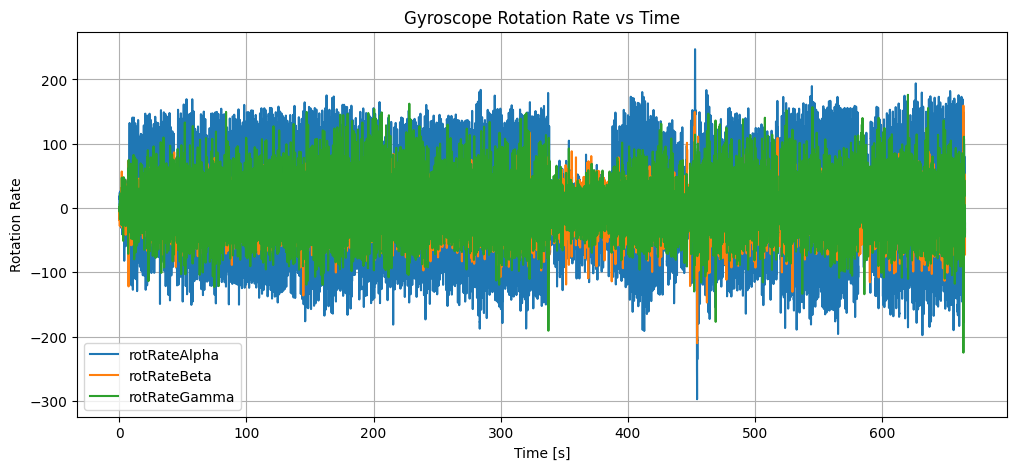

In [29]:
"""Gyroscope Rotation Rate vs Time """

x_vals = df_motion["ms"] / 1000

plt.figure(figsize=(12, 5))
plt.plot(x_vals, df_motion["rotRateAlpha"].values, label="rotRateAlpha")
plt.plot(x_vals, df_motion["rotRateBeta"].values, label="rotRateBeta")
plt.plot(x_vals, df_motion["rotRateGamma"].values, label="rotRateGamma")

plt.xlabel("Time [s]")
plt.ylabel("Rotation Rate")
plt.title("Gyroscope Rotation Rate vs Time")
plt.grid(True)
plt.legend()
plt.show()

The gyroscope signals are noise throughout the walk which is expected from a handheld device. The gyroscope captures the following: 
1. Hand swing 
2. Phone rotation
3. Turns
4. Sudden Heading changes


The gyroscope rotation rate signals show continuous rotational activity throughout the walk. Several high variation regions are visible, especially around 340–380 s, 420–450 s, and near 590 s. These regions overlap with changes observed in the acceleration magnitude and GNSS speed/heading plots. This suggests that some of the unusual acceleration and GNSS behavior may be related to phone rotation, hand movement, or route turns rather than purely missing data.

3.5 IMU-Data-Reference_cont_distance: The purpose of this task is to check does the distance increase smoothly, are there any major heading changes in the suspecious regions.

Text(0.5, 1.0, 'Disance vs Time')

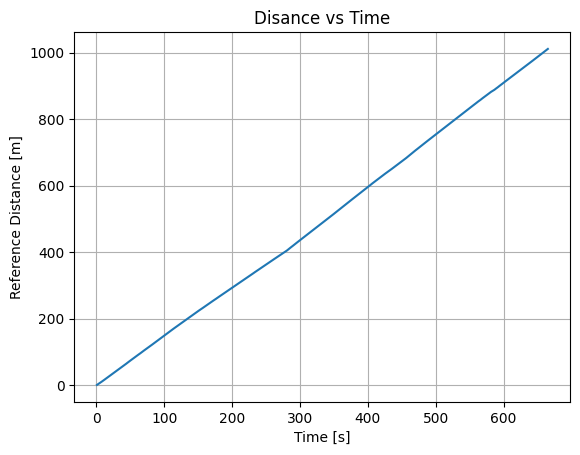

In [30]:
"""Reference Distance vs Time"""

df_ref_cont_dist.columns
x_vals=df_ref_cont_dist['ms'] / 1000
y_vals=df_ref_cont_dist['distance']

plt.plot(x_vals,y_vals)
plt.grid(True)
plt.xlabel("Time [s]")
plt.ylabel('Reference Distance [m]')
plt.title('Disance vs Time')

The participant seems to have walked continuously at a fairly stable pace. There are no obvious long flat regions, so there is no clear evidence of a long stop or pause in this reference-distance signal.

So the acceleration or gyroscope disturbances around those times are less likely to be long stops. They are more likely due to phone handling, turns, sensor artificates etc

3.6.IMU-Data-Steps

0.8678111587982833

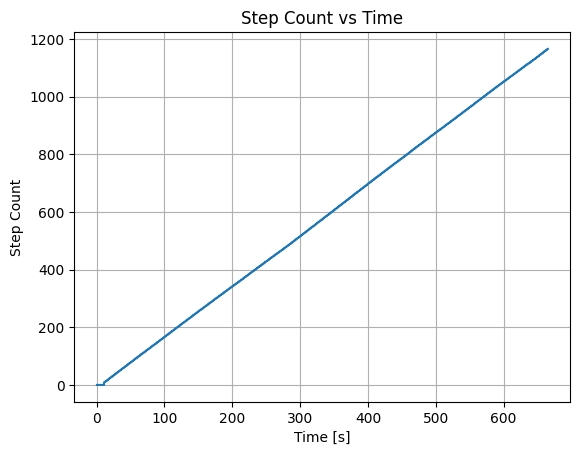

In [31]:
"""Steps vs Time"""

x_vals=df_steps['ms'] / 1000
y_vals=df_steps['steps']

plt.plot(x_vals,y_vals)
plt.grid(True)
plt.xlabel("Time [s]")
plt.ylabel('Step Count')
plt.title('Step Count vs Time')

avg_step_dist=max(df_ref_cont_dist['distance']) / (max(df_steps['steps'])) 
avg_step_dist


| Time region            | GNSS trajectory                                             | GNSS speed                                           | GNSS heading                                   | GNSS confidence                                                                       | Acceleration / magnitude                                                  | Gyroscope                                             | Orientation                                      | Reference distance                               | Steps                                    | Possible interpretation                                                                                             |
| ---------------------- | ----------------------------------------------------------- | ---------------------------------------------------- | ---------------------------------------------- | ------------------------------------------------------------------------------------- | ------------------------------------------------------------------------- | ----------------------------------------------------- | ------------------------------------------------ | ------------------------------------------------ | ---------------------------------------- | ------------------------------------------------------------------------------------------------------------------- |
| Start region, ~0–10 s  | Small irregularity near the beginning of the raw trajectory | Speed mostly normal after initial start              | Initial heading changes visible                | Large confidence spike, nearly ~29 m                                                  | Initial transition from low to active motion                              | Possible initial hand/phone movement                  | Should be checked for initial phone pose changes | Distance starts increasing normally              | Steps start increasing                   | Likely GNSS initialization / early signal stabilization rather than true abnormal walking                           |
| ~340–380 s             | Trajectory still appears continuous                         | Speed remains mostly within walking range            | No conclusion from heading alone               | Confidence appears mostly stable                                                      | Clear change in acceleration pattern; magnitude variability changes       | Gyroscope activity changes/reduces in this region     | Check if alpha/beta/gamma show phone pose change | Reference distance continues increasing smoothly | Step count continues increasing smoothly | Likely phone handling/posture change, walking-pattern change, or route/turn-related behavior; not a long stop       |
| ~420–450 s             | Possible local path/direction change                        | Speed spike above normal walking range around ~420 s | Sharp heading change / possible wrap-around    | Confidence interval increases around ~420–435 s                                       | Acceleration magnitude shows disturbance; accelZ spike/drop around ~450 s | Strong gyroscope spike/activity around ~450 s         | Check for orientation jump                       | Reference distance still increases smoothly      | Step count still increases smoothly      | Could be a real turn combined with phone rotation/handling; GNSS quality also worsens, so GNSS artifact is possible |
| ~590 s                 | Later trajectory region shows direction/path change         | Strong speed spike above 3 m/s                       | Heading shifts strongly toward final direction | Confidence does not appear as strongly bad as at start, but should be checked locally | Acceleration magnitude becomes more variable around 540–590 s             | Gyroscope activity/variation visible near this region | Check orientation around 590 s                   | Reference distance continues smoothly            | Step count continues smoothly            | Possible turn, sudden phone movement, GNSS speed artifact, or local route change; not likely a long stop            |
| End region, ~640–665 s | Final part of trajectory appears stable                     | Speed returns near normal walking range              | Heading relatively stable near final direction | Confidence stable around ~4 m                                                         | Motion continues until end                                                | Some rotation activity near end                       | Check if phone was moved/stopped after walk      | Reference distance reaches ~1011 m               | Step count reaches ~1165                 | Normal end of walking track; no major issue visible                                                                 |


Phase 3 conclusion: 

The cross-signal comparison shows that the suspicious regions are not caused by missing GNSS timestamps, since GNSS sampling is regular at 1 Hz. The reference distance and step count increase smoothly throughout the track, suggesting that the participant did not make long stops. Therefore, the unusual patterns around 340–380 s, 420–450 s, and ~590 s are more likely related to turns, phone handling, short gait changes, or local GNSS artifacts rather than long pauses. These regions should be considered during preprocessing and later GNSS–IMU fusion.

Phase 4: Time Alignment, Trimming and Coordinate preparation

Phase 4 prepares the selected track for preprocessing and sensor fusion. 

The goal is to trim all sensor streams to the official test window, normalize timestamps, convert GNSS latitude/longitude into local metric coordinates, and create aligned time references for GNSS, IMU, orientation, reference distance, and step data.

Phase 4.1: Official walking window

In [32]:
df_position.head(10)

,Unnamed: 0,ms,latitude,longitude,altitude,confInterval,heading,speed,time_gap_diff
0,0,4039.0,55.608629,13.004264,41.876038,7.572926,161.600006,1.45,0.0
1,1,5039.0,55.608620,13.004240,43.179199,6.511917,173.500000,1.27,1000.0
2,2,6039.0,55.608597,13.004232,44.870728,4.907988,178.100006,1.37,1000.0
3,3,5004.0,55.608201,13.004540,40.500000,28.943001,NaN,NaN,-1035.0
4,4,5009.0,55.608201,13.004540,40.500000,28.943001,NaN,NaN,5.0
5,5,5013.0,55.608201,13.004540,40.500000,28.943001,NaN,NaN,4.0
6,6,5022.0,55.608201,13.004540,40.500000,28.943001,NaN,NaN,9.0
7,7,7039.0,55.608579,13.004236,45.421814,4.282880,173.199997,1.45,2017.0
8,8,8039.0,55.608564,13.004244,47.250061,3.794236,174.500000,1.43,1000.0
9,9,9039.0,55.608553,13.004248,46.705383,3.790092,173.000000,1.43,1000.0


In [33]:
test_start_time=df_events['testStart'].iloc[0]
test_end_time=df_events['testEnd'].iloc[0]

# Preparing position data
df_position_prepared = df_position[
    (df_position["ms"] >= test_start_time) &
    (df_position["ms"] <= test_end_time)
].copy()
df_position_prepared.sort_values(by='ms', inplace=True,ignore_index=True)

# Preparing motion data
df_motion_prepared = df_motion[
    (df_motion["ms"] >= test_start_time) &
    (df_motion["ms"] <= test_end_time)
].copy()
df_motion_prepared.sort_values(by='ms', inplace=True,ignore_index=True)

# Preparing orientation data
df_orientation_prepared = df_orientation[
    (df_orientation["ms"] >= test_start_time) &
    (df_orientation["ms"] <= test_end_time)
].copy()
df_orientation_prepared.sort_values(by='ms', inplace=True,ignore_index=True)

# Preparing reference_cont_distance data
df_reference_cont_dist_prepared = df_ref_cont_dist[
    (df_ref_cont_dist["ms"] >= test_start_time) &
    (df_ref_cont_dist["ms"] <= test_end_time)
].copy()
df_reference_cont_dist_prepared.sort_values(by='ms', inplace=True,ignore_index=True)


# Preparing steps data
df_steps_prepared = df_steps[
    (df_steps["ms"] >= test_start_time) &
    (df_steps["ms"] <= test_end_time)
].copy()
df_steps_prepared.sort_values(by='ms', inplace=True, ignore_index=True)

prepared_streams = {
    "positions.csv": df_position_prepared,
    "motion.csv": df_motion_prepared,
    "orientation.csv": df_orientation_prepared,
    "reference_cont_distance.csv": df_reference_cont_dist_prepared,
    "steps.csv": df_steps_prepared,
}


output_check = []

for stream_name, stream_df in prepared_streams.items():
    first_ms = stream_df["ms"].iloc[0]
    last_ms = stream_df["ms"].iloc[-1]
    duration_s = (last_ms - first_ms) / 1000


    output_check.append(
        {
            "stream": stream_name,
            "first_ms_after_trimming": first_ms,
            "last_ms_after_trimming": last_ms,
            "duration_s": duration_s,
            "num_rows": len(stream_df),
            "num_columns": stream_df.shape[1],
        }
    )

output_check = pd.DataFrame(output_check)
output_check



,stream,first_ms_after_trimming,last_ms_after_trimming,duration_s,num_rows,num_columns
0,positions.csv,4039.0,665039.0,661.000,666,9
1,motion.csv,4042.0,665299.0,661.257,39628,12
2,orientation.csv,4043.0,665299.0,661.256,39450,6
3,reference_cont_distance.csv,4541.0,665210.0,660.669,1006,3
4,steps.csv,11091.0,665093.0,654.002,1165,8


Phase 4.2-Normalize Time stamps

The goal of this phase is to convert time in ms to sec and to normalize such that the start time of the official time is 0. And everything after that would be positive. 


In [34]:

for stream_name, stream_df in prepared_streams.items():
    time_sec = (stream_df['ms'] - test_start_time) / 1000
    stream_df['time_sec']=time_sec

df_position_prepared['time_sec'].head()

0    0.000
1    0.965
2    0.970
3    0.974
4    0.983
Name: time_sec, dtype: float64

Phase 4.3: Reset reference distance to start from 0

The goal of this phase is to convert the reference distance such that it starts from 0 and goes till the end. 

In [35]:
start_dist=df_reference_cont_dist_prepared['distance'].iloc[0]
ref_dist_norm = (df_reference_cont_dist_prepared['distance'] - start_dist)
df_reference_cont_dist_prepared['ref_dist_norm']=ref_dist_norm

df_reference_cont_dist_prepared['ref_dist_norm'].head()




0    0.0
1    1.0
2    2.0
3    3.0
4    4.0
Name: ref_dist_norm, dtype: float64

Phase 4.4 Convert GNSS latitude/longitude to local x-y meters



In [36]:
first_latitude=df_position_prepared['latitude'].iloc[0]
first_longitude=df_position_prepared['longitude'].iloc[0]

df_position_prepared['y_m']=(df_position_prepared['latitude'] - first_latitude) * 111320
df_position_prepared['x_m']=(df_position_prepared['longitude'] - first_longitude) * 111320 * np.cos(np.deg2rad(first_latitude))

df_position_prepared['x_m'].head()

0     0.000000
1    17.336174
2    17.336174
3    17.336174
4    17.336174
Name: x_m, dtype: float64

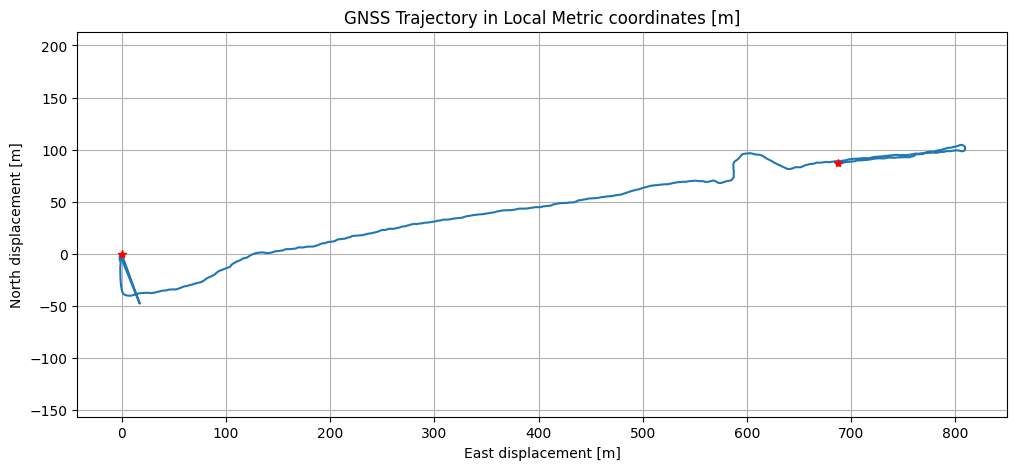

In [104]:
"""GNSS trajectory in meters"""

x_vals=df_position_prepared['x_m']
y_vals=df_position_prepared['y_m']

plt.figure(figsize=(12, 5))
plt.plot(x_vals,y_vals, marker='*',markevery=[0,-1], markerfacecolor='red', markeredgecolor='red')
plt.grid(True)
plt.xlabel("East displacement [m]")
plt.ylabel('North displacement [m]')
plt.title('GNSS Trajectory in Local Metric coordinates [m]')
plt.axis("equal")
plt.show()


After converting GNSS latitude and longitude to local metric coordinates, the trajectory starts at approximately (0, 0) and extends mainly in the eastward direction with a smaller northward displacement. The metric plot preserves the shape of the raw GNSS trajectory while allowing distance-based calculations such as path length, speed, and displacement.

Phase 4.5: calculating consecutive step distance from local xy coordinates

In [38]:
step_distances = [0.0]  

for i in range(1, len(df_position_prepared)):
    dx = df_position_prepared["x_m"].iloc[i] - df_position_prepared["x_m"].iloc[i - 1]
    dy = df_position_prepared["y_m"].iloc[i] - df_position_prepared["y_m"].iloc[i - 1]

    step_distance = (dx**2 + dy**2) ** 0.5
    step_distances.append(step_distance)

df_position_prepared["step_distance"] = step_distances
df_position_prepared["gnss_cumulative_distance"] = df_position_prepared["step_distance"].cumsum()

df_position_prepared[["time_sec", "x_m", "y_m", "step_distance", "gnss_cumulative_distance"]].head()

,time_sec,x_m,y_m,step_distance,gnss_cumulative_distance
0,0.000,0.000000,0.000000,0.00000,0.00000
1,0.965,17.336174,-47.754054,50.80347,50.80347
2,0.970,17.336174,-47.754054,0.00000,50.80347
3,0.974,17.336174,-47.754054,0.00000,50.80347
4,0.983,17.336174,-47.754054,0.00000,50.80347


Phase 4.5 Comput GNSS-derived speed from x-y distance

In [39]:
df_position_prepared[["time_sec", "time_gap_diff", "step_distance"]].head(10)

,time_sec,time_gap_diff,step_distance
0,0.000,0.0,0.000000
1,0.965,-1035.0,50.803470
2,0.970,5.0,0.000000
3,0.974,4.0,0.000000
4,0.983,9.0,0.000000
5,1.000,1000.0,50.368272
6,2.000,1000.0,2.588826
7,3.000,2017.0,2.058134
8,4.000,1000.0,1.698281
9,5.000,1000.0,1.328264


In [40]:
computed_speeds = [0.0]

for i in range(1, len(df_position_prepared)):
    distance = df_position_prepared["step_distance"].iloc[i]
    time_gap_s = df_position_prepared["time_gap_diff"].iloc[i] / 1000
    speed=0
    if time_gap_s > 0:
        speed = distance / time_gap_s
    else:
        speed=0

    computed_speeds.append(speed)

df_position_prepared["computed_speed"] = computed_speeds
df_position_prepared['speed_diff']=(df_position_prepared['computed_speed'] - df_position_prepared['speed'].abs())
df_position_prepared.loc[(df_position_prepared['time_sec']>= 580) &
                          (df_position_prepared['time_sec'] <600) ,["computed_speed", "speed",'speed_diff']]

,computed_speed,speed,speed_diff
584,1.627633,1.45,0.177633
585,1.645747,1.55,0.095747
586,1.543456,1.42,0.123456
587,3.138123,3.13,0.008123
588,3.159569,2.78,0.379569
589,2.215101,1.69,0.525101
590,1.809446,1.52,0.289446
591,1.454491,1.45,0.004491
592,1.498278,1.36,0.138278
593,1.479193,1.38,0.099193


In [41]:
df_position_prepared['ref_dist_at_gnss_time'] = np.interp(df_position_prepared["time_sec"] , df_reference_cont_dist_prepared['time_sec'], df_reference_cont_dist_prepared['ref_dist_norm'] )

In [42]:
df_position_prepared[[
    "time_sec",
    "gnss_cumulative_distance",
    "ref_dist_at_gnss_time"
]].head()

df_position_prepared['gnss_dist_error']=(df_position_prepared['gnss_cumulative_distance'] - df_position_prepared['ref_dist_at_gnss_time']).abs()

df_position_prepared['gnss_dist_error'].head()

0     0.000000
1    50.179481
2    50.172742
3    50.167351
4    50.155222
Name: gnss_dist_error, dtype: float64

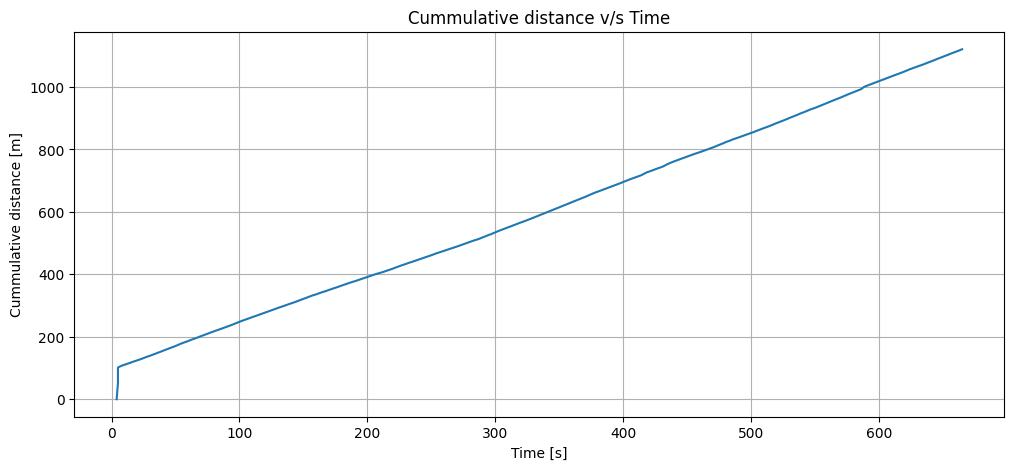

In [43]:
""" GNSS cummulative distance vs Time """

x_vals = df_position_prepared["ms"] / 1000
y_val = df_position_prepared['gnss_cumulative_distance']

plt.figure(figsize=(12, 5))
plt.plot(x_vals, y_val) 

plt.xlabel("Time [s]")
plt.ylabel("Cummulative distance [m]")
plt.title("Cummulative distance v/s Time")
plt.grid(True)
plt.show()

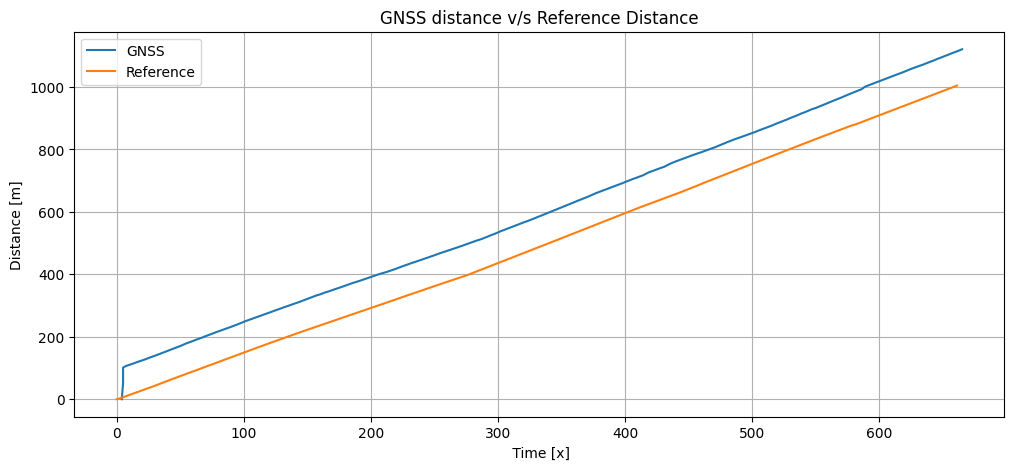

In [44]:
""" GNSS cummulative distance vs Ground truth """

x_val = df_position_prepared['time_sec']


plt.figure(figsize=(12, 5))
plt.plot(x_vals, df_position_prepared['gnss_cumulative_distance'].values, label= 'GNSS')
plt.plot(x_val, df_position_prepared["ref_dist_at_gnss_time"].values, label='Reference') 

plt.xlabel(" Time [x]")
plt.ylabel("Distance [m]")
plt.title("GNSS distance v/s Reference Distance")
plt.grid(True)
plt.legend()
plt.show()

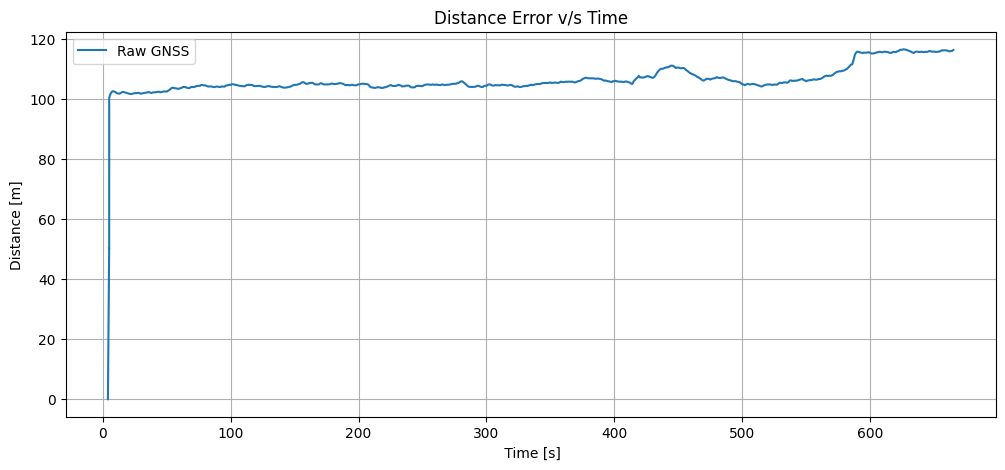

In [45]:
""" GNSS distance Error vs Time """

x_val = df_position_prepared['time_sec']

plt.figure(figsize=(12, 5))
plt.plot(x_vals, df_position_prepared['gnss_dist_error'].values, label= 'Raw GNSS')

plt.xlabel(" Time [s]")
plt.ylabel("Distance [m]")
plt.title("Distance Error v/s Time")
plt.grid(True)
plt.legend()
plt.show()

Raw GNSS cumulative distance contains early outlier-driven error, which motivates GNSS preprocessing before EKF fusion.

Phase 4.9: Align orientation to IMU timestamps
The goal here is that for every IMU sample, we estimate the orientation values alpha, beta and gamma at the same timestamp

In [46]:
# Target timeline: IMU/motion timestamps
imu_time = df_motion_prepared["time_sec"].values

# Known orientation timeline
ori_time = df_orientation_prepared["time_sec"].values

# Interpolate orientation angles onto IMU timestamps
df_motion_prepared["alpha_at_imu_time"] = np.interp(
    imu_time,
    ori_time,
    df_orientation_prepared["alpha"].values
)

df_motion_prepared["beta_at_imu_time"] = np.interp(
    imu_time,
    ori_time,
    df_orientation_prepared["beta"].values
)

df_motion_prepared["gamma_at_imu_time"] = np.interp(
    imu_time,
    ori_time,
    df_orientation_prepared["gamma"].values
)

# Check result
df_motion_prepared[
    [
        "time_sec",
        "accelX",
        "accelY",
        "accelZ",
        "rotRateAlpha",
        "rotRateBeta",
        "rotRateGamma",
        "alpha_at_imu_time",
        "beta_at_imu_time",
        "gamma_at_imu_time",
    ]
].head()

,time_sec,accelX,accelY,accelZ,rotRateAlpha,rotRateBeta,rotRateGamma,alpha_at_imu_time,beta_at_imu_time,gamma_at_imu_time
0,0.003,0.0,0.5,-1.2,8.2,21.0,10.6,96.3,13.1,-1.8
1,0.020,0.0,0.6,-2.5,10.8,28.4,10.2,96.5,13.4,-1.2
2,0.036,-0.1,0.6,-3.0,12.2,31.8,10.0,96.6,13.6,-0.9
3,0.053,0.2,0.7,-3.3,14.7,28.8,9.8,96.8,14.0,-0.5
4,0.069,0.4,0.7,-3.5,19.2,23.4,8.3,96.9,14.2,-0.3


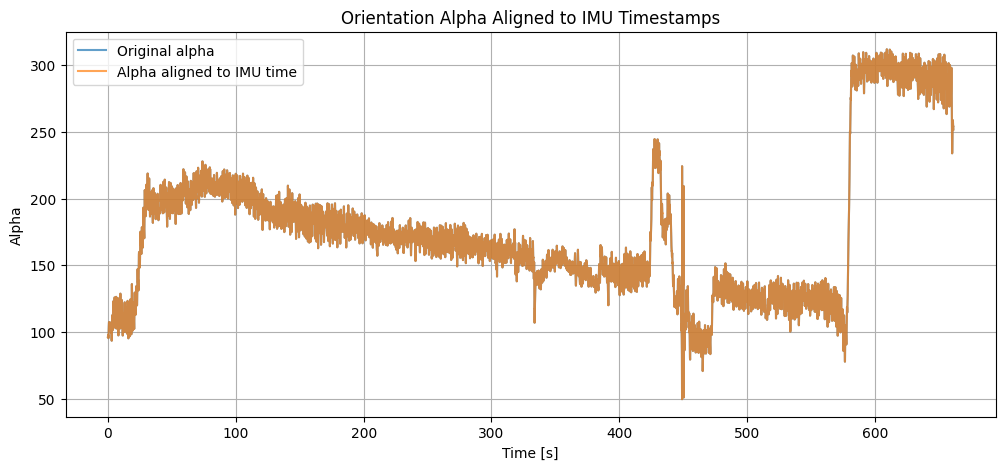

In [47]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_orientation_prepared["time_sec"],
    df_orientation_prepared["alpha"],
    label="Original alpha",
    alpha=0.7
)

plt.plot(
    df_motion_prepared["time_sec"],
    df_motion_prepared["alpha_at_imu_time"],
    label="Alpha aligned to IMU time",
    alpha=0.7
)

plt.xlabel("Time [s]")
plt.ylabel("Alpha")
plt.title("Orientation Alpha Aligned to IMU Timestamps")
plt.grid(True)
plt.legend()
plt.show()

The orientation alpha signal was interpolated onto the IMU timestamps. The aligned signal closely overlaps with the original orientation signal, confirming that the interpolation worked correctly. The alpha angle changes substantially throughout the walk, especially around 430–470 s and near 580 s. These regions overlap with earlier acceleration, gyroscope, and GNSS heading changes, suggesting that some signal irregularities may be caused by phone orientation or handling changes.

Phase 4.10 — IMU time intervals


In [48]:

df_motion_prepared['time_gap_diff']=0
for i in range(1,len(df_motion_prepared)):
               df_motion_prepared.loc[df_motion_prepared.index[i], 'time_gap_diff']=(df_motion_prepared['ms'].iloc[i] - df_motion_prepared['ms'].iloc[i-1])

df_motion_prepared['time_gap_diff'].describe()


count    39628.000000
mean        16.686610
std          1.976832
min          0.000000
25%         16.000000
50%         17.000000
75%         17.000000
max        111.000000
Name: time_gap_diff, dtype: float64

In [49]:
df_motion_prepared.loc[df_motion_prepared['time_gap_diff'] > 50,['time_sec', 'time_gap_diff' , 'ms']].count()

time_sec         11
time_gap_diff    11
ms               11
dtype: int64

In [50]:
df_motion_prepared.iloc[df_motion_prepared['time_gap_diff'] > 50]
df_motion_prepared['dt_s'] = df_motion_prepared['time_gap_diff'].values / 1000

The IMU time interval analysis shows that most samples are recorded every 16–17 ms, which corresponds to approximately 60 Hz and matches the metadata sampling frequency. However, 11 gaps larger than 50 ms were detected, with the maximum gap around 111 ms. These gaps are relatively small in number but should be considered during EKF prediction, since larger dt values increase uncertainty in IMU-based propagation.

In [51]:
df_motion_prepared.to_csv("results/df_motion_prepared.csv", index=False)
df_position_prepared.to_csv("results/df_position_prepared.csv", index=False)
df_orientation_prepared.to_csv("results/df_orientation_prepared.csv", index=False)
df_reference_cont_dist_prepared.to_csv("results/df_reference_cont_dist_prepared.csv", index=False)
df_steps_prepared.to_csv("results/df_steps_prepared.csv", index=False)

Phase 5 — GNSS Preprocessing and Outlier Handling

In [52]:
df_position_prepared['speed'].describe()

count    662.000000
mean       1.457870
std        0.142362
min        1.040000
25%        1.390000
50%        1.450000
75%        1.520000
max        3.130000
Name: speed, dtype: float64

In [53]:
# Flag based on step_distance
df_position_prepared["flag_step_distance"] = 0
df_position_prepared.loc[
    (df_position_prepared["step_distance"] > 3) |
    (df_position_prepared["step_distance"].isna()),
    "flag_step_distance"
] = 1

# Flag based on computed_speed
df_position_prepared["flag_computed_speed"] = 0
df_position_prepared.loc[
    (df_position_prepared["computed_speed"] > 3) |
    (df_position_prepared["computed_speed"].isna()),
    "flag_computed_speed"
] = 1

# Flag based on confInterval
df_position_prepared["flag_confInterval"] = 0
df_position_prepared.loc[
    (df_position_prepared["confInterval"] > 7) |
    (df_position_prepared["confInterval"].isna()),
    "flag_confInterval"
] = 1

# Flag based on GNSS reported speed
df_position_prepared["flag_speed"] = 0
df_position_prepared.loc[
    (df_position_prepared["speed"] > 3) |
    (df_position_prepared["speed"].isna()),
    "flag_speed"
] = 1

In [54]:
df_position_prepared["gnss_outlier"] = 0

df_position_prepared.loc[
    (df_position_prepared["flag_step_distance"] == 1) |
    (df_position_prepared["flag_computed_speed"] == 1) |
    (df_position_prepared["flag_confInterval"] == 1) |
    (df_position_prepared["flag_speed"] == 1),
    "gnss_outlier"
] = 1

In [55]:
df_position_prepared.loc[
    df_position_prepared["gnss_outlier"] == 1,
    [
        "time_sec",
        "step_distance",
        "computed_speed",
        "speed",
        "confInterval",
        "heading",
        "flag_step_distance",
        "flag_computed_speed",
        "flag_confInterval",
        "flag_speed",
        "gnss_outlier"
    ]
]

,time_sec,step_distance,computed_speed,speed,confInterval,heading,flag_step_distance,flag_computed_speed,flag_confInterval,flag_speed,gnss_outlier
0,0.000,0.000000,0.000000,1.45,7.572926,161.600006,0,0,1,0,1
1,0.965,50.803470,0.000000,NaN,28.943001,NaN,1,0,1,1,1
2,0.970,0.000000,0.000000,NaN,28.943001,NaN,0,0,1,1,1
3,0.974,0.000000,0.000000,NaN,28.943001,NaN,0,0,1,1,1
4,0.983,0.000000,0.000000,NaN,28.943001,NaN,0,0,1,1,1
5,1.000,50.368272,50.368272,1.27,6.511917,173.500000,1,1,0,0,1
587,583.000,3.138123,3.138123,3.13,3.790092,4.500000,1,1,0,1,1
588,584.000,3.159569,3.159569,2.78,3.790092,305.799988,1,1,0,0,1


In [56]:
gnss_check_cols = [
    "ms",
    "time_sec",
    "latitude",
    "longitude",
    "x_m",
    "y_m",
    "confInterval",
    "speed",
    "heading",
    "step_distance",
    "computed_speed",
    "gnss_cumulative_distance",
    "ref_dist_at_gnss_time",
    "gnss_dist_error",
]

df_position_prepared[gnss_check_cols].isna().sum()

ms                          0
time_sec                    0
latitude                    0
longitude                   0
x_m                         0
y_m                         0
confInterval                0
speed                       4
heading                     4
step_distance               0
computed_speed              0
gnss_cumulative_distance    0
ref_dist_at_gnss_time       0
gnss_dist_error             0
dtype: int64

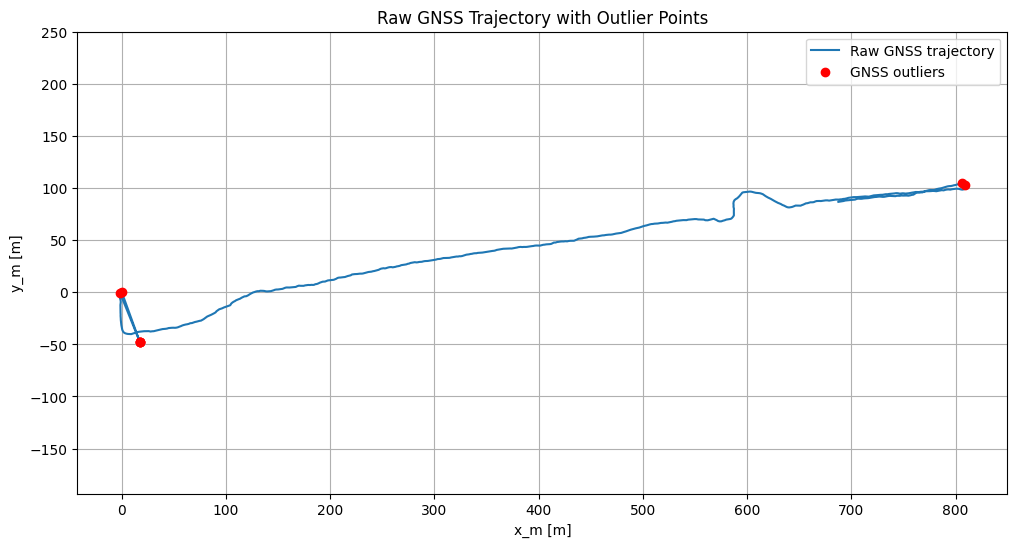

In [57]:
normal_points = df_position_prepared[df_position_prepared["gnss_outlier"] == 0]
outlier_points = df_position_prepared[df_position_prepared["gnss_outlier"] == 1]
plt.figure(figsize=(12, 6))

plt.plot(
    df_position_prepared["x_m"],
    df_position_prepared["y_m"],
    label="Raw GNSS trajectory"
)

plt.scatter(
    outlier_points["x_m"],
    outlier_points["y_m"],
    color="red",
    label="GNSS outliers",
    zorder=5
)

plt.xlabel("x_m [m]")
plt.ylabel("y_m [m]")
plt.title("Raw GNSS Trajectory with Outlier Points")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.show()

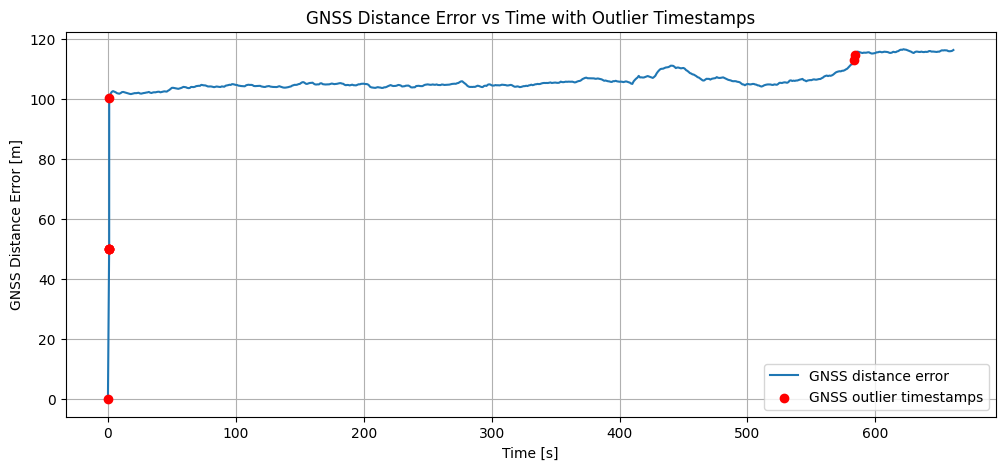

In [58]:
outlier_points = df_position_prepared[df_position_prepared["gnss_outlier"] == 1]

plt.figure(figsize=(12, 5))

plt.plot(
    df_position_prepared["time_sec"],
    df_position_prepared["gnss_dist_error"],
    label="GNSS distance error"
)

plt.scatter(
    outlier_points["time_sec"],
    outlier_points["gnss_dist_error"],
    color="red",
    label="GNSS outlier timestamps",
    zorder=5
)

plt.xlabel("Time [s]")
plt.ylabel("GNSS Distance Error [m]")
plt.title("GNSS Distance Error vs Time with Outlier Timestamps")
plt.grid(True)
plt.legend()
plt.show()

I decided not to blindly remove or interpolate all problematic GNSS samples. Instead, I created quality flags based on physical walking constraints and GNSS quality indicators. This allows the EKF to skip or down weight unreliable GNSS updates while preserving the time structure of the full sensor sequence.

PHASE 6: IMU preprocessing and Error Handling
The goal of this phase is to inspect and prepare the accelerometer and gyroscope signas for motion analysis and later for EKF prediction.

IMU is affected by phone orientation, hand motion, sensor noise and bias. Therefore we cannot use the raw IMU signals for EKF prediction. 

Phase 6.1:Inspecting Null values for IMU


In [59]:
cols=df_motion_prepared.columns
df_motion_prepared[cols].isna().sum()

Unnamed: 0           0
ms                   0
accelX               0
accelY               0
accelZ               0
accelWithGX          0
accelWithGY          0
accelWithGZ          0
rotRateAlpha         0
rotRateBeta          0
rotRateGamma         0
interval             0
time_sec             0
alpha_at_imu_time    0
beta_at_imu_time     0
gamma_at_imu_time    0
time_gap_diff        0
dt_s                 0
dtype: int64

There are no null values present. That doesnt mean there are no outliers we have to check the important cols and see if there any any feature values which are obvious IMU sensor artifcates. 

Phase 6.2: Flaging obvious IMU sensor artifactes

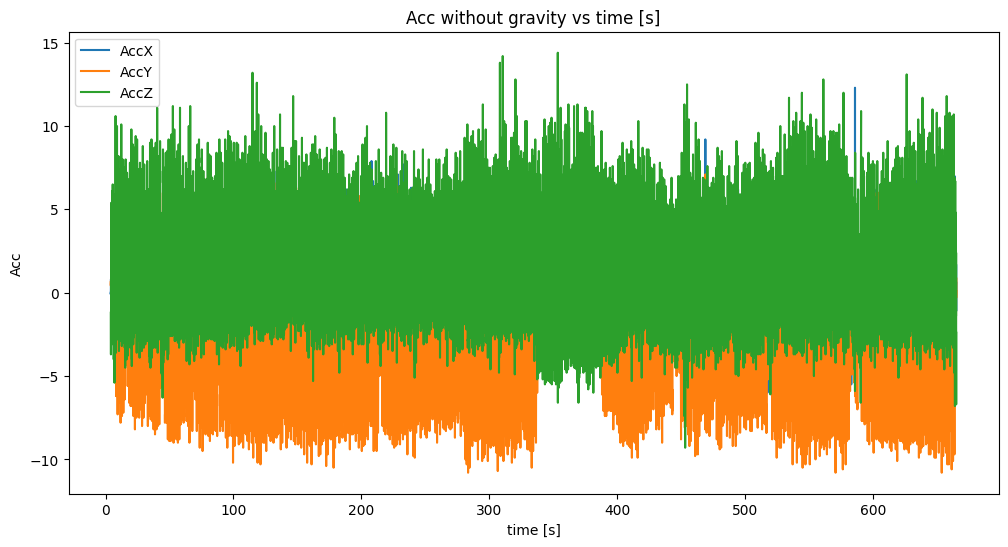

,accelX,accelY,accelZ
count,39628.000000,39628.000000,39628.000000
mean,0.156617,-0.776938,0.979022
std,2.110139,3.912111,3.118040
min,-7.700000,-10.800000,-9.300000
25%,-1.400000,-3.900000,-1.400000
50%,0.000000,0.000000,0.300000
75%,1.500000,2.500000,3.100000
max,12.300000,7.400000,14.400000


In [60]:
acc_cols=['accelX', 'accelY','accelZ']
acc_withg_cols=['accelWithGX','accelWithGY', 'accelWithGZ']
gyro_cols=['rotRateAlpha', 'rotRateBeta', 'rotRateGamma']
label_acc=['AccX', 'AccY', 'AccZ']  
gyro=['Alpha', 'Beta', 'Gamma']  
plt.figure(figsize=(12, 6))
x_vals=df_motion_prepared['ms'] / 1000
plt.plot(x_vals, df_motion_prepared[acc_cols], label=label_acc)
plt.xlabel('time [s]')
plt.ylabel('Acc')
plt.title('Acc without gravity vs time [s]')
plt.legend()
plt.show()

df_motion_prepared[acc_cols].describe()

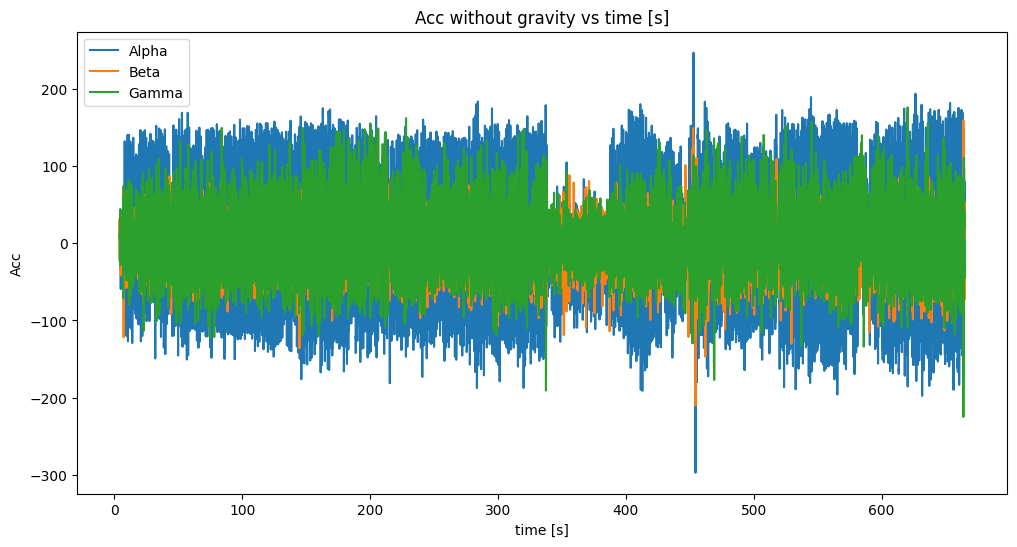

,rotRateAlpha,rotRateBeta,rotRateGamma
count,39628.000000,39628.000000,39628.000000
mean,-0.258645,-3.245501,0.607194
std,86.089074,31.366716,41.085786
min,-297.300000,-210.100000,-224.900000
25%,-71.100000,-25.900000,-26.500000
50%,-12.500000,-1.500000,-1.000000
75%,80.400000,20.300000,26.300000
max,247.000000,159.300000,176.100000


In [61]:
x_vals=df_motion_prepared['ms'] / 1000

plt.figure(figsize=(12, 6))

plt.plot(x_vals, df_motion_prepared[gyro_cols], label=gyro)
plt.xlabel('time [s]')
plt.ylabel('Acc')
plt.title('Acc without gravity vs time [s]')
plt.legend()
plt.show()


df_motion_prepared[gyro_cols].describe()

Calculating Magnitude Acceleration, Gyroscope

In [62]:
df_motion_prepared["acc_mag_with_g"] = np.sqrt(
    df_motion_prepared["accelWithGX"]**2 +
    df_motion_prepared["accelWithGY"]**2 +
    df_motion_prepared["accelWithGZ"]**2
)

df_motion_prepared["acc_mag_without_g"] = np.sqrt(
    df_motion_prepared["accelX"]**2 +
    df_motion_prepared["accelY"]**2 +
    df_motion_prepared["accelZ"]**2
)

df_motion_prepared["gyro_mag"] = np.sqrt(
    df_motion_prepared["rotRateAlpha"]**2 +
    df_motion_prepared["rotRateBeta"]**2 +
    df_motion_prepared["rotRateGamma"]**2
)

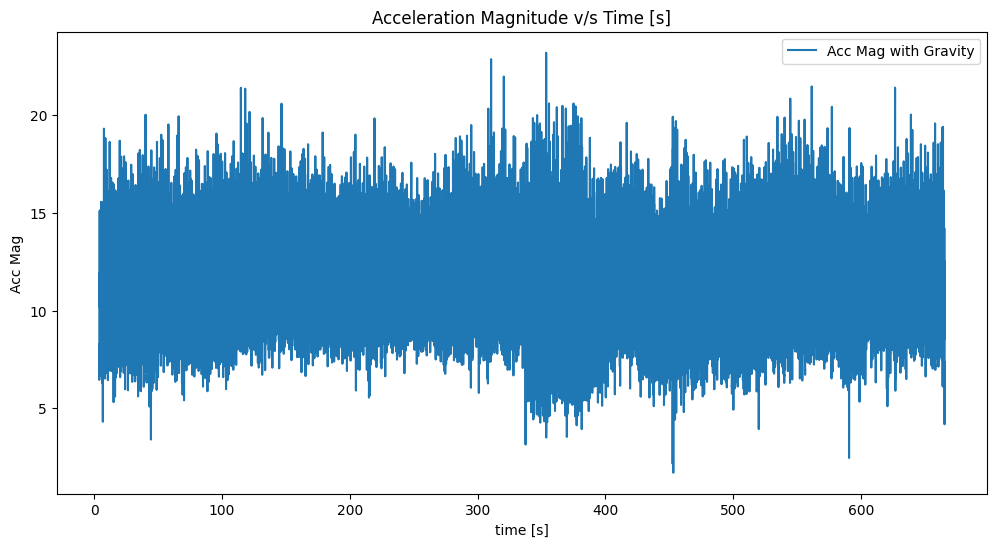

In [63]:
x_vals=df_motion_prepared['ms'] / 1000
plt.figure(figsize=(12, 6))
plt.plot(x_vals, df_motion_prepared['acc_mag_with_g'], label='Acc Mag with Gravity')
plt.xlabel('time [s]')
plt.ylabel('Acc Mag')
plt.title('Acceleration Magnitude v/s Time [s]')
plt.legend()
plt.show()

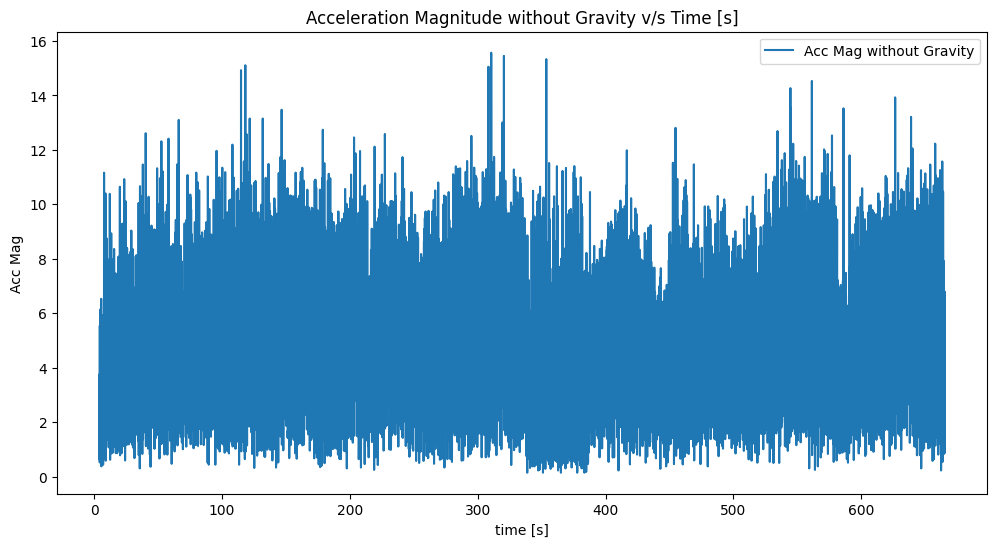

In [64]:
x_vals=df_motion_prepared['ms'] / 1000
plt.figure(figsize=(12, 6))
plt.plot(x_vals, df_motion_prepared['acc_mag_without_g'], label='Acc Mag without Gravity')
plt.xlabel('time [s]')
plt.ylabel('Acc Mag')
plt.title('Acceleration Magnitude without Gravity v/s Time [s]')
plt.legend()
plt.show()

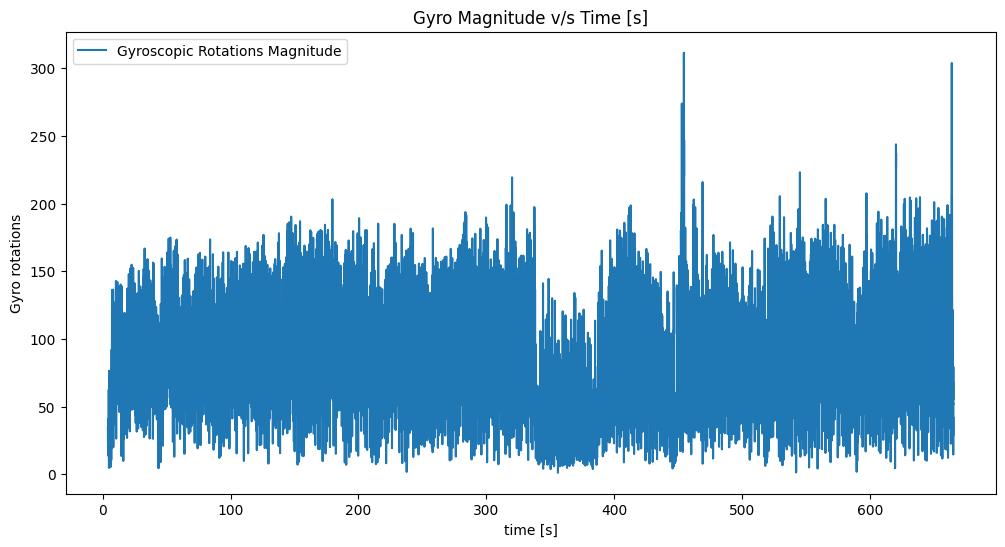

In [65]:
x_vals=df_motion_prepared['ms'] / 1000
plt.figure(figsize=(12, 6))
plt.plot(x_vals, df_motion_prepared['gyro_mag'], label='Gyroscopic Rotations Magnitude')
plt.xlabel('time [s]')
plt.ylabel('Gyro rotations')
plt.title('Gyro Magnitude v/s Time [s]')
plt.legend()
plt.show()

In [66]:
"""Acceleration Threshold"""

acc_threshold = (
    df_motion_prepared["acc_mag_without_g"].mean()
    + 3 * df_motion_prepared["acc_mag_without_g"].std()
)

df_motion_prepared["flag_acc_mag_without_g"] = 0

df_motion_prepared.loc[
    df_motion_prepared["acc_mag_without_g"] > acc_threshold,
    "flag_acc_mag_without_g"
] = 1

"""Gyroscopic Threshold"""
gyro_threshold = (
    df_motion_prepared["gyro_mag"].mean()
    + 3 * df_motion_prepared["gyro_mag"].std()
)

df_motion_prepared["flag_gyro_mag"] = 0

df_motion_prepared.loc[
    df_motion_prepared["gyro_mag"] > gyro_threshold,
    "flag_gyro_mag"
] = 1

"""Threshold based on IMU time gap"""
df_motion_prepared["flag_imu_gap"] = 0

df_motion_prepared.loc[
    df_motion_prepared["dt_s"] > 0.05,
    "flag_imu_gap"
] = 1

"""Final IMU Outliers"""
df_motion_prepared["imu_suspicious"] = 0

df_motion_prepared.loc[
    (df_motion_prepared["flag_acc_mag_without_g"] == 1) |
    (df_motion_prepared["flag_gyro_mag"] == 1) |
    (df_motion_prepared["flag_imu_gap"] == 1),
    "imu_suspicious"
] = 1
""" Inspecting Flabs Based on Flags"""
df_motion_prepared.loc[
    df_motion_prepared["imu_suspicious"] == 1,
    [
        "time_sec",
        "dt_s",
        "acc_mag_without_g",
        "gyro_mag",
        "flag_acc_mag_without_g",
        "flag_gyro_mag",
        "flag_imu_gap",
        "imu_suspicious"
    ]
]


,time_sec,dt_s,acc_mag_without_g,gyro_mag,flag_acc_mag_without_g,flag_gyro_mag,flag_imu_gap,imu_suspicious
2024,33.839,0.111,2.071232,78.833369,0,0,1,1
2171,36.285,0.017,12.614278,44.179067,1,0,0,1
2172,36.301,0.016,12.404435,45.181855,1,0,0,1
2907,48.551,0.016,12.317467,51.706963,1,0,0,1
3242,54.134,0.013,12.414910,35.406497,1,0,0,1
...,...,...,...,...,...,...,...,...
39551,659.993,0.016,6.303174,299.188335,0,1,0,1
39552,660.010,0.017,4.318565,303.833688,0,1,0,1
39553,660.026,0.016,4.180909,286.269698,0,1,0,1
39554,660.048,0.022,3.414674,229.548557,0,1,0,1


Phase 6.5: Bias / Offset Inspection Gyroscope

Ideally if acceleration has gravity removed and the phone has no real acceleration over a long period the average should be close to 0m/s^2. But in real sensors that is not the case, often with IMU sensors there is a small offset, and this offset is called as bias. 

In my case I am assuming the bias to stay constant over the all period, but it may also be effected by other effects like phone orientation, hand movements, sensor noise.

In [67]:
"""Bias Correction without Gravity"""
df_motion_prepared['bias_corrected_accx'] = (df_motion_prepared['accelX'] - df_motion_prepared['accelX'].mean())
df_motion_prepared['bias_corrected_accy'] = (df_motion_prepared['accelY'] - df_motion_prepared['accelY'].mean())
df_motion_prepared['bias_corrected_accz'] = (df_motion_prepared['accelZ'] - df_motion_prepared['accelZ'].mean())

"""Bias Correction with Gravity"""
df_motion_prepared['bias_corrected_accx_withg'] = (df_motion_prepared['accelWithGX'] - df_motion_prepared['accelWithGX'].mean())
df_motion_prepared['bias_corrected_accy_withg'] = (df_motion_prepared['accelWithGY'] - df_motion_prepared['accelWithGY'].mean())
df_motion_prepared['bias_corrected_accz_withg'] = (df_motion_prepared['accelWithGZ'] - df_motion_prepared['accelWithGZ'].mean())

"""Recomputing Magnitude with Gravity"""
df_motion_prepared["bias_corrected_acc_mag_with_g"] = np.sqrt(
    df_motion_prepared["bias_corrected_accx_withg"]**2 +
    df_motion_prepared["bias_corrected_accy_withg"]**2 +
    df_motion_prepared["bias_corrected_accz_withg"]**2
)

"""Recomputing Magnitude without Gravity"""
df_motion_prepared["bias_corrected_acc_mag_without_g"] = np.sqrt(
    df_motion_prepared["bias_corrected_accx"]**2 +
    df_motion_prepared["bias_corrected_accy"]**2 +
    df_motion_prepared["bias_corrected_accz"]**2
)


In [68]:
"""Recomputing Acceleration Magnitude"""

df_motion_prepared["bias_corrected_acc_mag_without_g"] = np.sqrt(
    df_motion_prepared["bias_corrected_accx"]**2 +
    df_motion_prepared["bias_corrected_accy"]**2 +
    df_motion_prepared["bias_corrected_accz"]**2
)

In [69]:
df_motion_prepared[
    ["bias_corrected_accx", "bias_corrected_accy", "bias_corrected_accz"]
].mean()

bias_corrected_accx    4.590162e-17
bias_corrected_accy    7.459013e-17
bias_corrected_accz   -9.180324e-17
dtype: float64

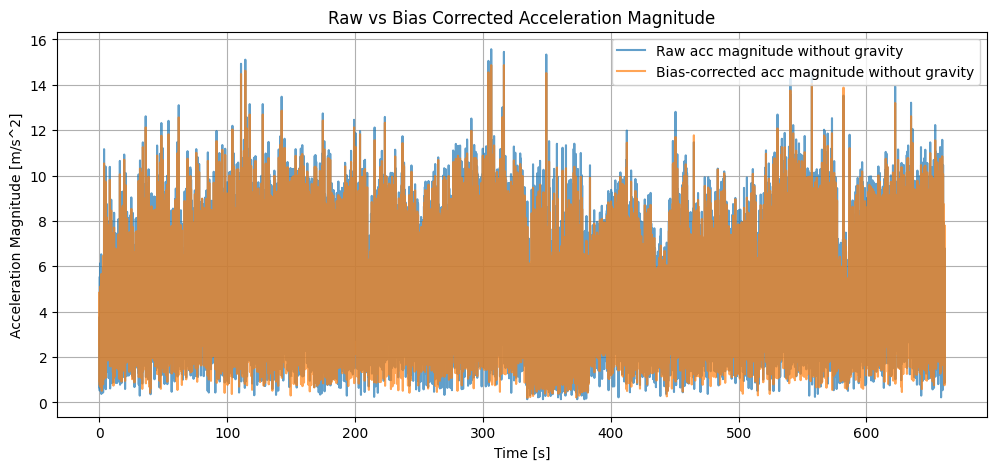

In [70]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_motion_prepared["time_sec"],
    df_motion_prepared["acc_mag_without_g"],
    label="Raw acc magnitude without gravity",
    alpha=0.7
)

plt.plot(
    df_motion_prepared["time_sec"],
    df_motion_prepared["bias_corrected_acc_mag_without_g"],
    label="Bias-corrected acc magnitude without gravity",
    alpha=0.7
)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration Magnitude [m/s^2]")
plt.title("Raw vs Bias Corrected Acceleration Magnitude")
plt.grid(True)
plt.legend()
plt.show()

Phase 6.6: Smooth / filter IMU signals using rolling mean
The raw IMU plots are noisy and need light smoothing for good visualization and feature stability. 

In [71]:
window_size = 15  # around 0.25 seconds at ~60 Hz

df_motion_prepared["acc_mag_smooth"] = (
    df_motion_prepared["bias_corrected_acc_mag_without_g"]
    .rolling(window=window_size, center=True)
    .mean()
)

df_motion_prepared["gyro_mag_smooth"] = (
    df_motion_prepared["gyro_mag"]
    .rolling(window=window_size, center=True)
    .mean()
)

#filling na values cause by rolling mean

df_motion_prepared["acc_mag_smooth"] = (
    df_motion_prepared["acc_mag_smooth"]
    .bfill()
    .ffill()
)

df_motion_prepared["gyro_mag_smooth"] = (
    df_motion_prepared["gyro_mag_smooth"]
    .bfill()
    .ffill()
)

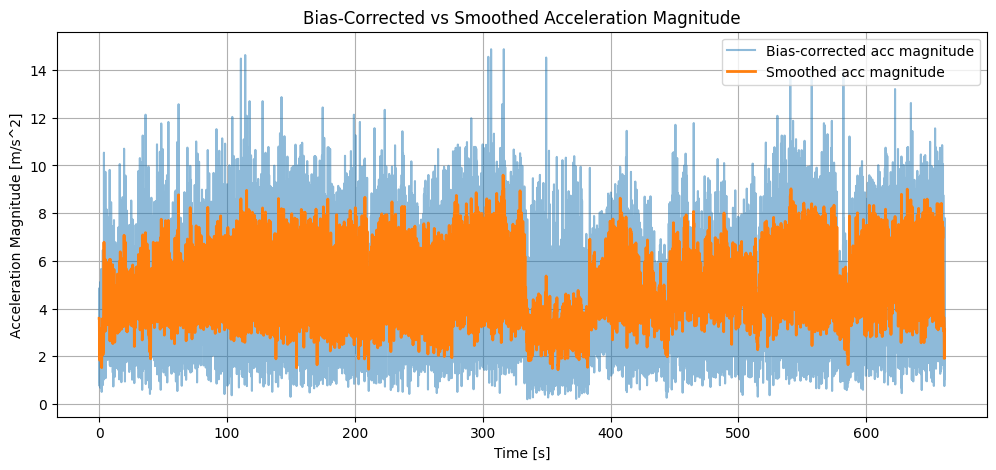

In [72]:
"""Plotting Bias Corrected acceleration v/s Smoothed acceleration"""
plt.figure(figsize=(12, 5))

plt.plot(
    df_motion_prepared["time_sec"],
    df_motion_prepared["bias_corrected_acc_mag_without_g"],
    label="Bias-corrected acc magnitude",
    alpha=0.5
)

plt.plot(
    df_motion_prepared["time_sec"],
    df_motion_prepared["acc_mag_smooth"],
    label="Smoothed acc magnitude",
    linewidth=2
)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration Magnitude [m/s^2]")
plt.title("Bias-Corrected vs Smoothed Acceleration Magnitude")
plt.grid(True)
plt.legend()
plt.show()

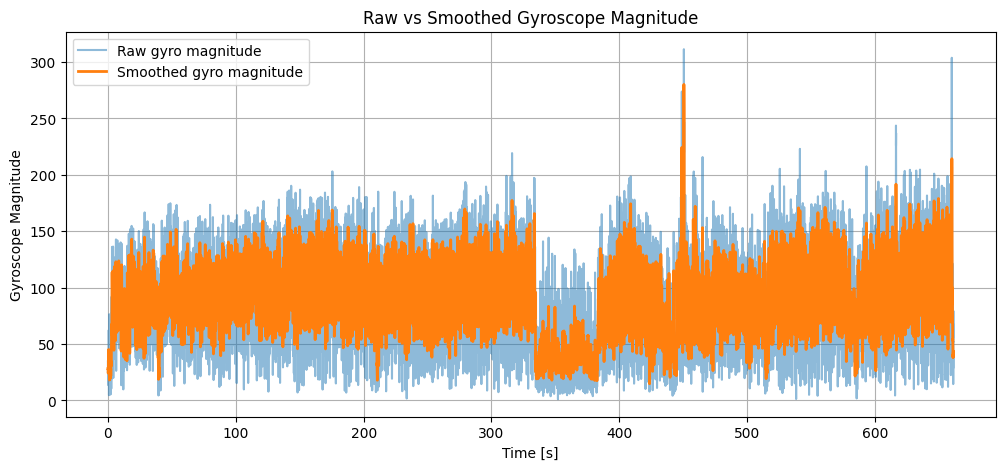

In [73]:
"""Plotting Raw gyro v/s Smoothed gyro magnitude"""
plt.figure(figsize=(12, 5))

plt.plot(
    df_motion_prepared["time_sec"],
    df_motion_prepared["gyro_mag"],
    label="Raw gyro magnitude",
    alpha=0.5
)

plt.plot(
    df_motion_prepared["time_sec"],
    df_motion_prepared["gyro_mag_smooth"],
    label="Smoothed gyro magnitude",
    linewidth=2
)

plt.xlabel("Time [s]")
plt.ylabel("Gyroscope Magnitude")
plt.title("Raw vs Smoothed Gyroscope Magnitude")
plt.grid(True)
plt.legend()
plt.show()

Phase 7: Baseline Comparision before EKF

The goal of this phase is to show how GNSS-only trajectories behaves, how IMU-only trajectory behaves and why sensor fusion is required. 

GNSS-only baseline trajectory

In [74]:
df_position_prepared.columns

Index(['Unnamed: 0', 'ms', 'latitude', 'longitude', 'altitude', 'confInterval',
       'heading', 'speed', 'time_gap_diff', 'time_sec', 'y_m', 'x_m',
       'step_distance', 'gnss_cumulative_distance', 'computed_speed',
       'speed_diff', 'ref_dist_at_gnss_time', 'gnss_dist_error',
       'flag_step_distance', 'flag_computed_speed', 'flag_confInterval',
       'flag_speed', 'gnss_outlier'],
      dtype='str')

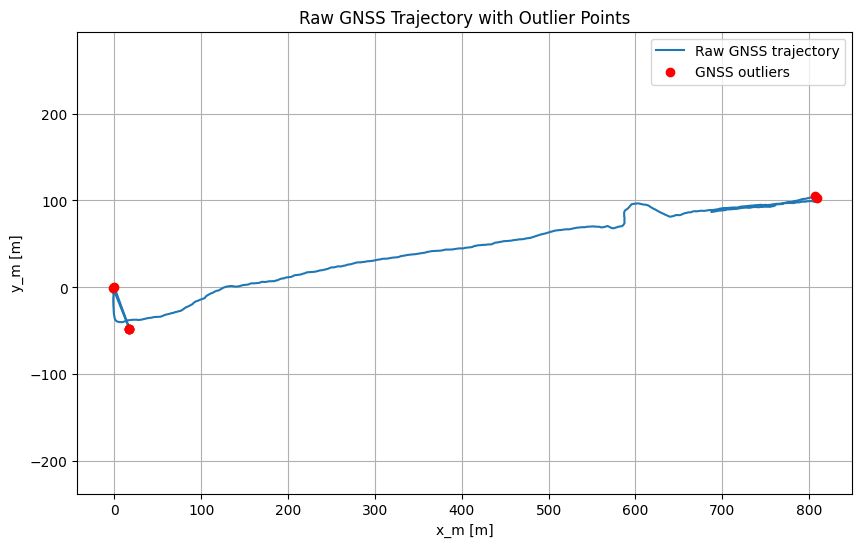

In [75]:
""" Raw GNSS trajectory with outliers"""
x_vals = df_position_prepared["x_m"]
y_vals = df_position_prepared["y_m"]

outlier_points = df_position_prepared[df_position_prepared["gnss_outlier"] == 1]

plt.figure(figsize=(10, 6))

plt.plot(x_vals, y_vals, label="Raw GNSS trajectory")

plt.scatter(
    outlier_points["x_m"],
    outlier_points["y_m"],
    color="red",
    label="GNSS outliers",
    zorder=5
)

plt.xlabel("x_m [m]")
plt.ylabel("y_m [m]")
plt.title("Raw GNSS Trajectory with Outlier Points")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.show()

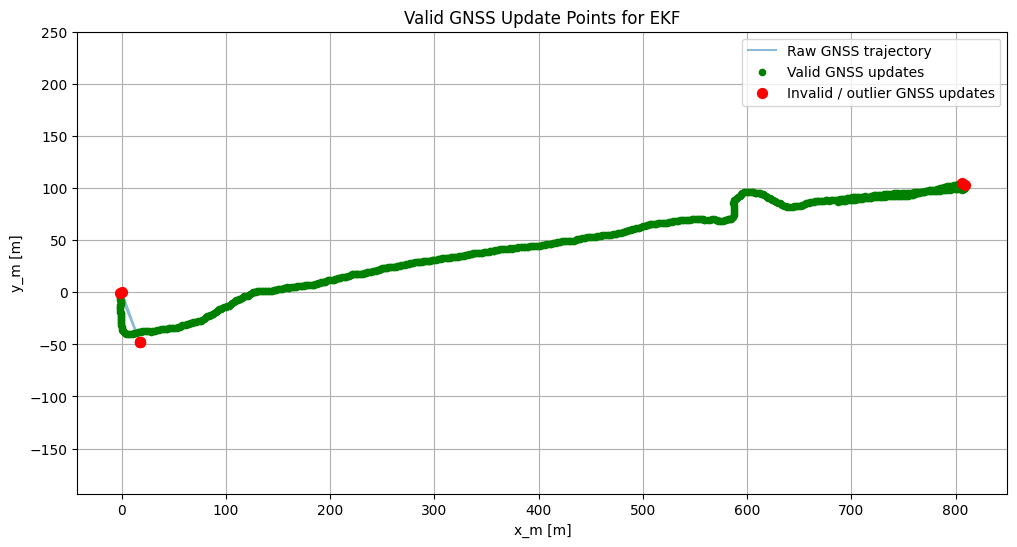

In [76]:
""" Valid GNSS update points"""

valid_points = df_position_prepared[df_position_prepared["gnss_outlier"] == 0]
outlier_points = df_position_prepared[df_position_prepared["gnss_outlier"] == 1]

plt.figure(figsize=(12, 6))

plt.plot(
    df_position_prepared["x_m"],
    df_position_prepared["y_m"],
    label="Raw GNSS trajectory",
    alpha=0.5
)

plt.scatter(
    valid_points["x_m"],
    valid_points["y_m"],
    color="green",
    s=20,
    label="Valid GNSS updates",
    zorder=4
)

plt.scatter(
    outlier_points["x_m"],
    outlier_points["y_m"],
    color="red",
    s=50,
    label="Invalid / outlier GNSS updates",
    zorder=5
)

plt.xlabel("x_m [m]")
plt.ylabel("y_m [m]")
plt.title("Valid GNSS Update Points for EKF")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.show()

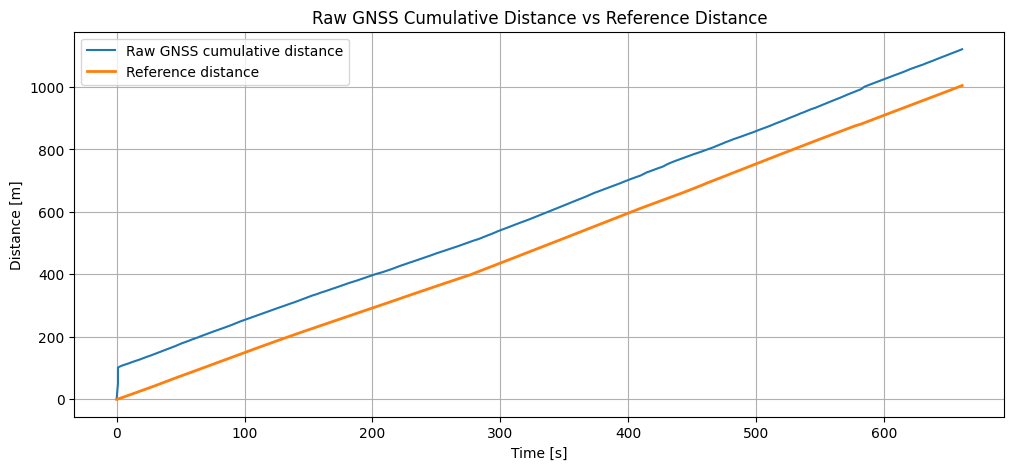

In [77]:
""" GNSS cumulative distance v/s refrence distance"""
plt.figure(figsize=(12, 5))

plt.plot(
    df_position_prepared["time_sec"],
    df_position_prepared["gnss_cumulative_distance"],
    label="Raw GNSS cumulative distance"
)

plt.plot(
    df_position_prepared["time_sec"],
    df_position_prepared["ref_dist_at_gnss_time"],
    label="Reference distance",
    linewidth=2
)

plt.xlabel("Time [s]")
plt.ylabel("Distance [m]")
plt.title("Raw GNSS Cumulative Distance vs Reference Distance")
plt.grid(True)
plt.legend()
plt.show()

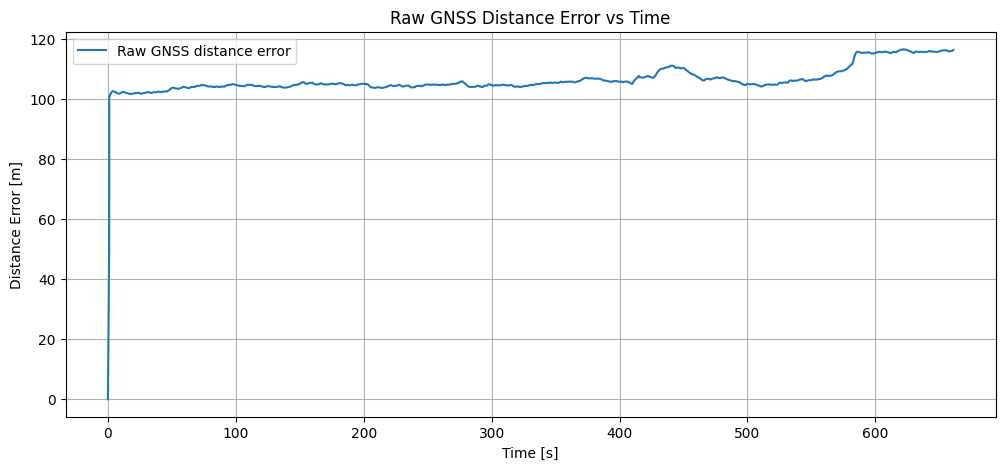

In [78]:
"""Distance error v/s time with outliers"""
plt.figure(figsize=(12, 5))

plt.plot(
    df_position_prepared["time_sec"],
    df_position_prepared["gnss_dist_error"],
    label="Raw GNSS distance error"
)

plt.xlabel("Time [s]")
plt.ylabel("Distance Error [m]")
plt.title("Raw GNSS Distance Error vs Time")
plt.grid(True)
plt.legend()
plt.show()

Phase 7.2: IMU-only baseline trajectory

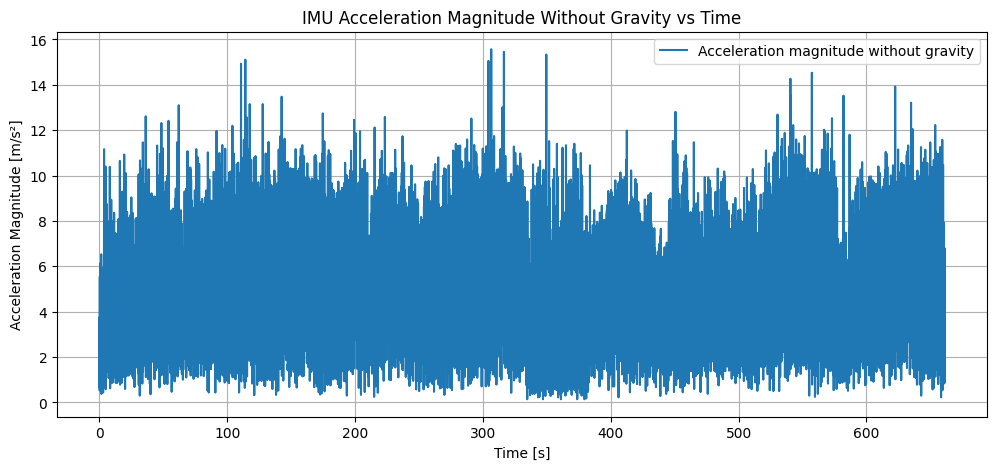

In [79]:
'''Acceleration magnitude without gravity'''
plt.figure(figsize=(12, 5))

plt.plot(
    df_motion_prepared["time_sec"],
    df_motion_prepared["acc_mag_without_g"],
    label="Acceleration magnitude without gravity"
)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration Magnitude [m/s²]")
plt.title("IMU Acceleration Magnitude Without Gravity vs Time")
plt.grid(True)
plt.legend()
plt.show()

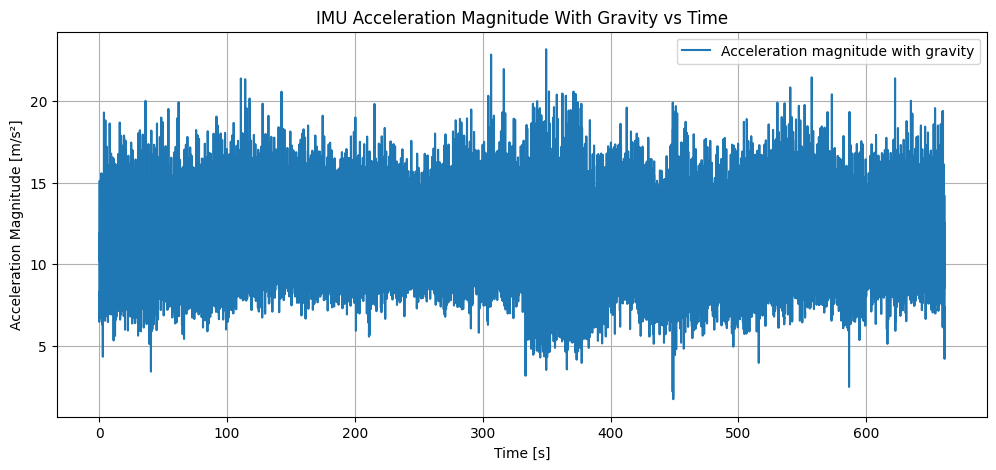

In [80]:
"""Acceleration magnitude with gravity"""
plt.figure(figsize=(12, 5))

plt.plot(
    df_motion_prepared["time_sec"],
    df_motion_prepared["acc_mag_with_g"],
    label="Acceleration magnitude with gravity"
)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration Magnitude [m/s²]")
plt.title("IMU Acceleration Magnitude With Gravity vs Time")
plt.grid(True)
plt.legend()
plt.show()

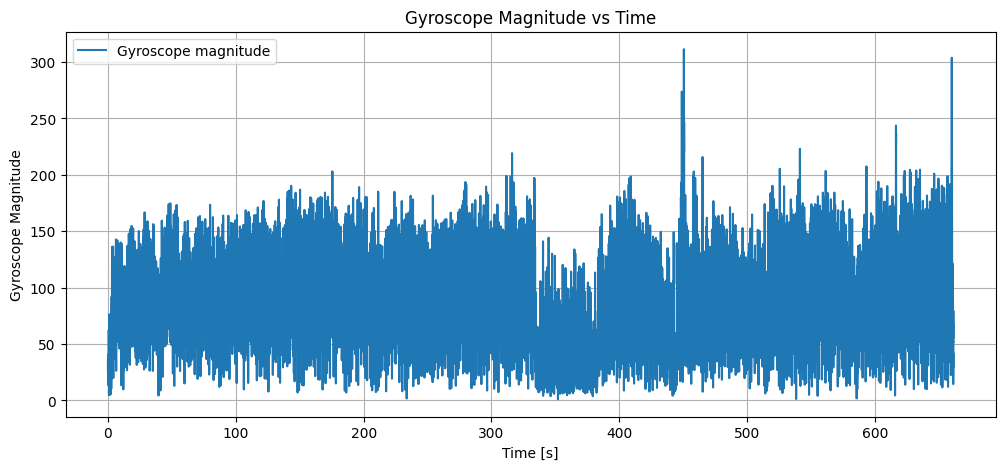

In [81]:
"""Gyroscope magnitude"""
plt.figure(figsize=(12, 5))

plt.plot(
    df_motion_prepared["time_sec"],
    df_motion_prepared["gyro_mag"],
    label="Gyroscope magnitude"
)

plt.xlabel("Time [s]")
plt.ylabel("Gyroscope Magnitude")
plt.title("Gyroscope Magnitude vs Time")
plt.grid(True)
plt.legend()
plt.show()

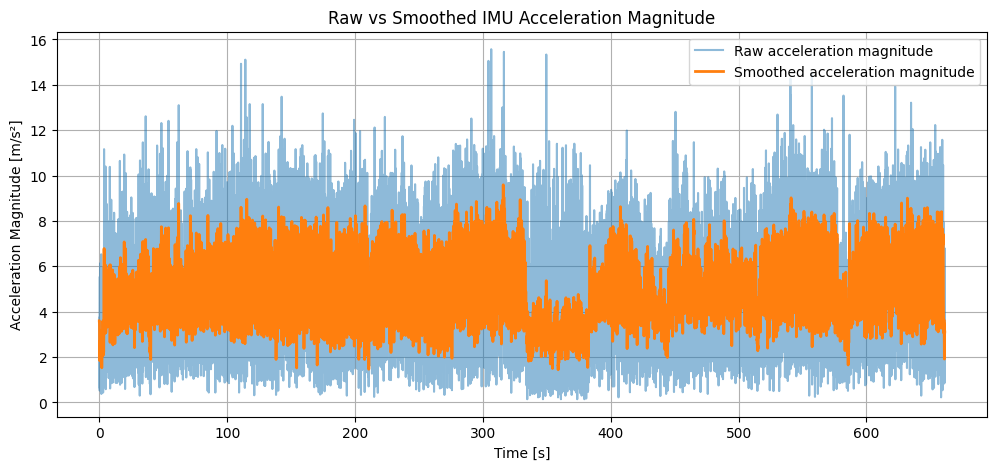

In [105]:
"""Raw vs smoothed acceleration magnitude"""
plt.figure(figsize=(12, 5))

plt.plot(
    df_motion_prepared["time_sec"],
    df_motion_prepared["acc_mag_without_g"],
    label="Raw acceleration magnitude",
    alpha=0.5
)

plt.plot(
    df_motion_prepared["time_sec"],
    df_motion_prepared["acc_mag_smooth"],
    label="Smoothed acceleration magnitude",
    linewidth=2
)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration Magnitude [m/s²]")
plt.title("Raw vs Smoothed IMU Acceleration Magnitude")
plt.grid(True)
plt.legend()
plt.show()

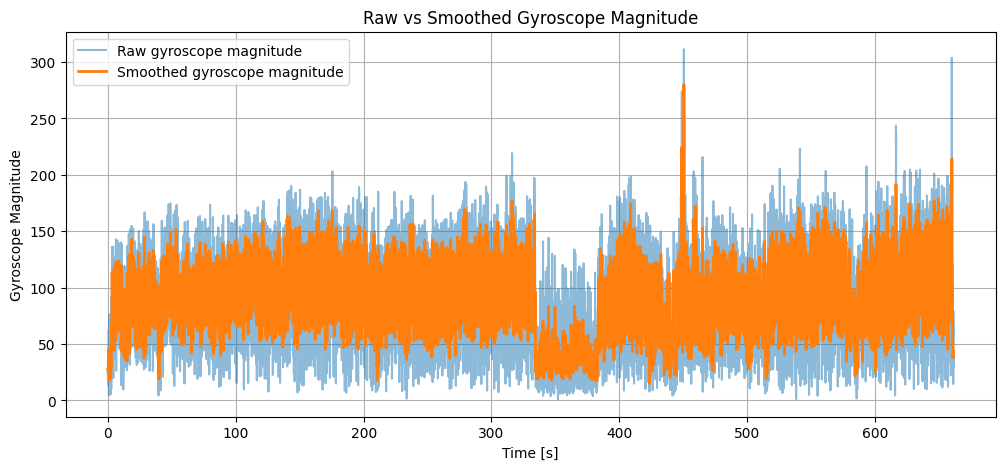

In [83]:
""" Raw vs smoothed gyroscope magnitude"""
plt.figure(figsize=(12, 5))

plt.plot(
    df_motion_prepared["time_sec"],
    df_motion_prepared["gyro_mag"],
    label="Raw gyroscope magnitude",
    alpha=0.5
)

plt.plot(
    df_motion_prepared["time_sec"],
    df_motion_prepared["gyro_mag_smooth"],
    label="Smoothed gyroscope magnitude",
    linewidth=2
)

plt.xlabel("Time [s]")
plt.ylabel("Gyroscope Magnitude")
plt.title("Raw vs Smoothed Gyroscope Magnitude")
plt.grid(True)
plt.legend()
plt.show()

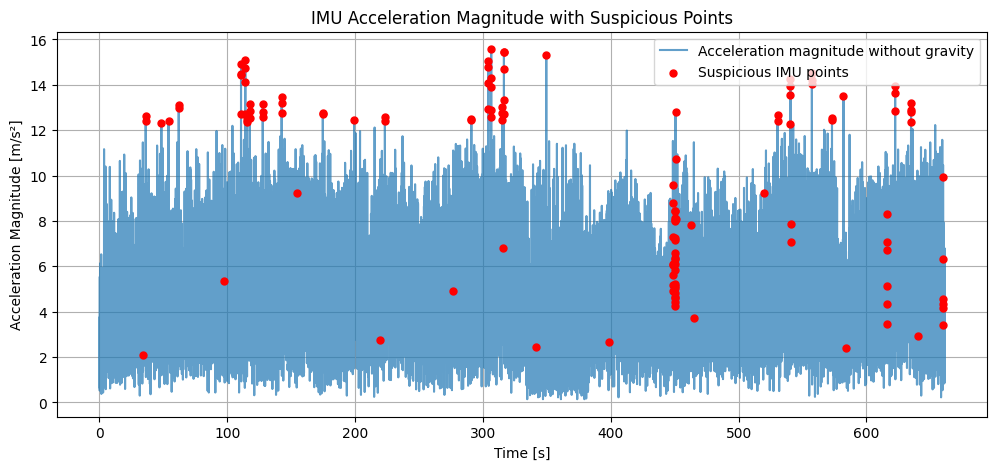

In [84]:
"""Acceleration Magnitude with Suspecious points"""
suspicious_imu = df_motion_prepared[df_motion_prepared["imu_suspicious"] == 1]

plt.figure(figsize=(12, 5))

plt.plot(
    df_motion_prepared["time_sec"],
    df_motion_prepared["acc_mag_without_g"],
    label="Acceleration magnitude without gravity",
    alpha=0.7
)

plt.scatter(
    suspicious_imu["time_sec"],
    suspicious_imu["acc_mag_without_g"],
    color="red",
    s=25,
    label="Suspicious IMU points",
    zorder=5
)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration Magnitude [m/s²]")
plt.title("IMU Acceleration Magnitude with Suspicious Points")
plt.grid(True)
plt.legend()
plt.show()

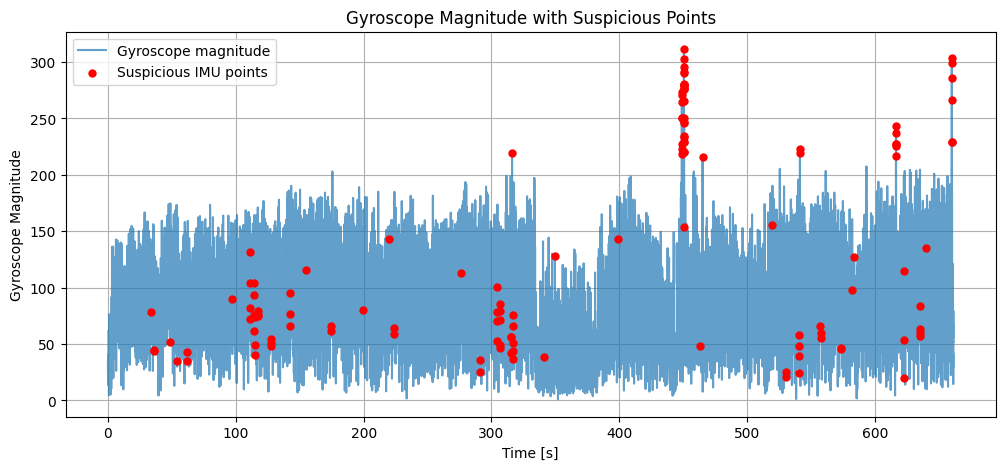

In [85]:
"""Gyroscope magnitude with suspicious points"""
suspicious_imu = df_motion_prepared[df_motion_prepared["imu_suspicious"] == 1]

plt.figure(figsize=(12, 5))

plt.plot(
    df_motion_prepared["time_sec"],
    df_motion_prepared["gyro_mag"],
    label="Gyroscope magnitude",
    alpha=0.7
)

plt.scatter(
    suspicious_imu["time_sec"],
    suspicious_imu["gyro_mag"],
    color="red",
    s=25,
    label="Suspicious IMU points",
    zorder=5
)

plt.xlabel("Time [s]")
plt.ylabel("Gyroscope Magnitude")
plt.title("Gyroscope Magnitude with Suspicious Points")
plt.grid(True)
plt.legend()
plt.show()

Phase 8: Initial Kalman-filter-based trajectory estimation

In this phase, I implement a first-stage Kalman Filter using a constant-velocity motion model and valid GNSS position updates. GNSS measurements flagged as outliers are skipped during correction. The IMU preprocessing from the previous phase prepares motion features that can later be incorporated into a full EKF with orientation correction and acceleration-based prediction.  

In [86]:
df_position_prepared['valid_gnss_updates']=(df_position_prepared["gnss_outlier"] == 0).astype(int)

In [106]:
#Kalman filter implementation
first_valid = df_position_prepared[df_position_prepared["valid_gnss_updates"] == 1].iloc[0]

x_m=first_valid['x_m']
y_m=first_valid['y_m']

vx0 = 0.0
vy0 = 0.0

initial_states=[x_m, y_m, vx0, vy0] # initial state (x_m-east direction, y_m-north, vx-velocityx, vy-velocityy)

kf=KalmanFilter(dim_x=4, dim_z=2) # (dim_x=no of states, dim_z=measurment variables: x_gnss, y_gnss)

kf.x = np.array([[x_m], [y_m], [vx0], [vy0]], dtype=float)

kf.H = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
])                  #measurment matrix h 


kf.P = np.diag([
    10.0,   # x uncertainty
    10.0,   # y uncertainty
    100.0,  # vx uncertainty
    100.0   # vy uncertainty
])

kf.R=np.array([
    [16.0, 0.0],        #confidence interval is around 4m 
    [0.0, 16.0]

])

kf.Q=np.eye(4) * 0.1    # process noise Q


In [88]:
kf_results = []

prev_time = df_position_prepared["time_sec"].iloc[0]

for idx, row in df_position_prepared.iterrows():

    current_time = row["time_sec"]
    dt = current_time - prev_time

    # Safety check
    if dt < 0:
        dt = 0.0

    # State transition matrix for constant velocity model
    kf.F = np.array([
        [1, 0, dt, 0],
        [0, 1, 0, dt],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ], dtype=float)

    # Prediction step
    kf.predict()

    used_gnss_update = 0

    # Correction step only if GNSS is valid
    if row["valid_gnss_updates"] == 1:
        z = np.array([row["x_m"], row["y_m"]], dtype=float)
        kf.update(z)
        used_gnss_update = 1

    # Save result
    kf_results.append({
        "time_sec": current_time,
        "kf_x": float(kf.x[0,0]),
        "kf_y": float(kf.x[1,0]),
        "kf_vx": float(kf.x[2,0]),
        "kf_vy": float(kf.x[3,0]),
        "used_gnss_update": used_gnss_update,
        "gnss_outlier": row["gnss_outlier"],
        "valid_gnss_updates": row["valid_gnss_updates"]
    })

    prev_time = current_time

df_kf = pd.DataFrame(kf_results)

df_kf.head()

,time_sec,kf_x,kf_y,kf_vx,kf_vy,used_gnss_update,gnss_outlier,valid_gnss_updates
0,0.000,-2.015878,-3.594523,0.0,0.0,0,1.0,0.0
1,0.965,-2.015878,-3.594523,0.0,0.0,0,1.0,0.0
2,0.970,-2.015878,-3.594523,0.0,0.0,0,1.0,0.0
3,0.974,-2.015878,-3.594523,0.0,0.0,0,1.0,0.0
4,0.983,-2.015878,-3.594523,0.0,0.0,0,1.0,0.0


In [ ]:
#KF step distance and cumulative distance

kf_step_distances = [0.0]

for i in range(1, len(df_kf)):
    dx = df_kf["kf_x"].iloc[i] - df_kf["kf_x"].iloc[i - 1]
    dy = df_kf["kf_y"].iloc[i] - df_kf["kf_y"].iloc[i - 1]

    step_dist = (dx**2 + dy**2) ** 0.5
    kf_step_distances.append(step_dist)

df_kf["kf_step_distance"] = kf_step_distances
df_kf["kf_cumulative_distance"] = df_kf["kf_step_distance"].cumsum()

df_kf[["time_sec", "kf_x", "kf_y", "kf_step_distance", "kf_cumulative_distance"]].head()

,time_sec,kf_x,kf_y,kf_step_distance,kf_cumulative_distance
0,0.000,-2.015878,-3.594523,0.0,0.0
1,0.965,-2.015878,-3.594523,0.0,0.0
2,0.970,-2.015878,-3.594523,0.0,0.0
3,0.974,-2.015878,-3.594523,0.0,0.0
4,0.983,-2.015878,-3.594523,0.0,0.0


In [90]:

# Align reference distance to KF timestamps
df_kf["ref_dist_at_kf_time"] = np.interp(
    df_kf["time_sec"],
    df_reference_cont_dist_prepared["time_sec"],
    df_reference_cont_dist_prepared["ref_dist_norm"]
)

df_kf["kf_dist_error"] = (
    df_kf["kf_cumulative_distance"] - df_kf["ref_dist_at_kf_time"]
)

df_kf[[
    "time_sec",
    "kf_cumulative_distance",
    "ref_dist_at_kf_time",
    "kf_dist_error"
]].head()

,time_sec,kf_cumulative_distance,ref_dist_at_kf_time,kf_dist_error
0,0.000,0.0,0.000000,0.000000
1,0.965,0.0,0.623989,-0.623989
2,0.970,0.0,0.630728,-0.630728
3,0.974,0.0,0.636119,-0.636119
4,0.983,0.0,0.648248,-0.648248


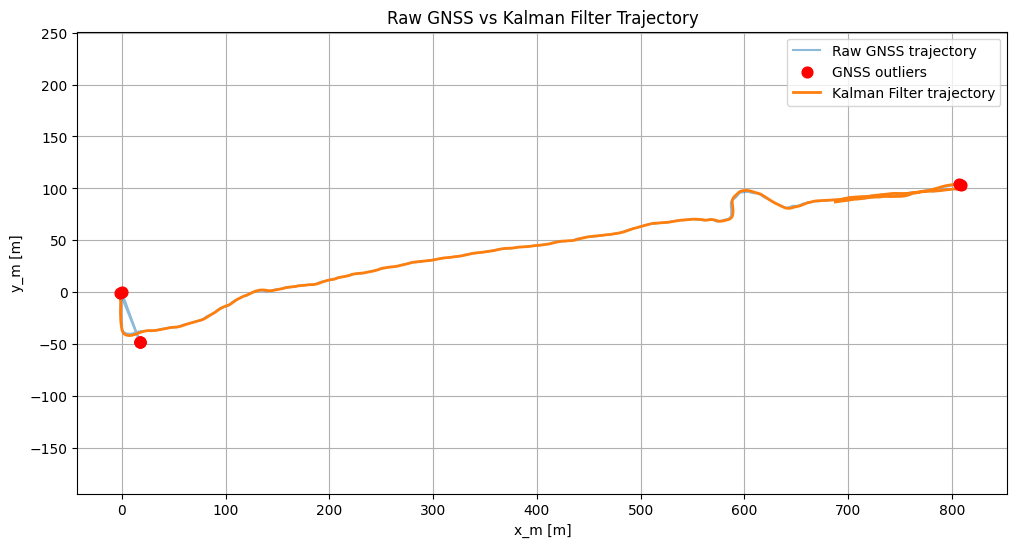

In [91]:
outlier_points = df_position_prepared[df_position_prepared["gnss_outlier"] == 1]
valid_points = df_position_prepared[df_position_prepared["valid_gnss_updates"] == 1]

plt.figure(figsize=(12, 6))

plt.plot(
    df_position_prepared["x_m"],
    df_position_prepared["y_m"],
    label="Raw GNSS trajectory",
    alpha=0.5
)

plt.scatter(
    outlier_points["x_m"],
    outlier_points["y_m"],
    color="red",
    s=60,
    label="GNSS outliers",
    zorder=5
)

plt.plot(
    df_kf["kf_x"],
    df_kf["kf_y"],
    label="Kalman Filter trajectory",
    linewidth=2
)

plt.xlabel("x_m [m]")
plt.ylabel("y_m [m]")
plt.title("Raw GNSS vs Kalman Filter Trajectory")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.show()

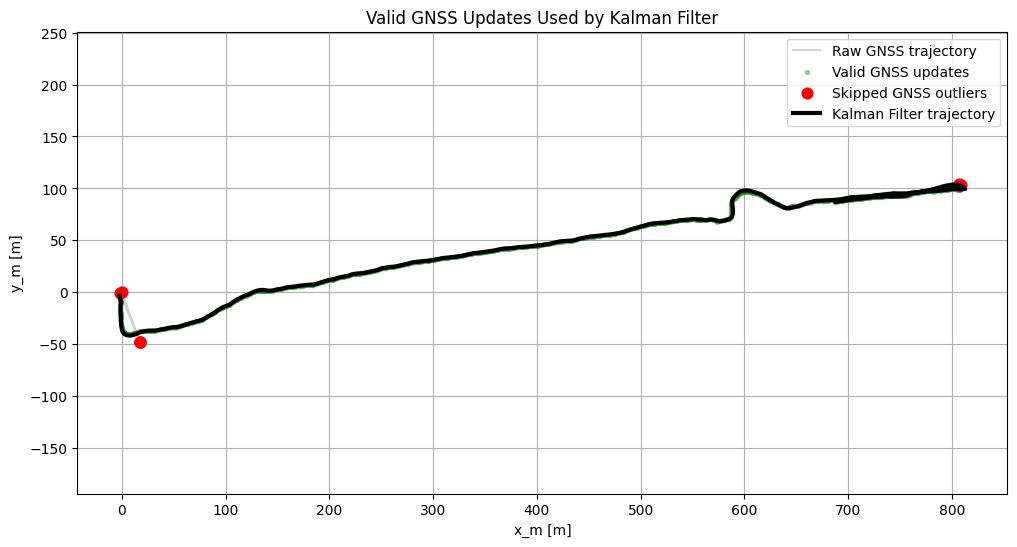

In [92]:
plt.figure(figsize=(12, 6))

# Raw GNSS trajectory as background
plt.plot(
    df_position_prepared["x_m"],
    df_position_prepared["y_m"],
    color="gray",
    alpha=0.35,
    label="Raw GNSS trajectory",
    zorder=1
)

# Valid GNSS update points
plt.scatter(
    valid_points["x_m"],
    valid_points["y_m"],
    color="green",
    s=8,
    alpha=0.35,
    label="Valid GNSS updates",
    zorder=3
)

# Skipped outliers
plt.scatter(
    outlier_points["x_m"],
    outlier_points["y_m"],
    color="red",
    s=60,
    label="Skipped GNSS outliers",
    zorder=8
)

# Kalman trajectory on top
plt.plot(
    df_kf["kf_x"],
    df_kf["kf_y"],
    color="black",
    linewidth=3,
    label="Kalman Filter trajectory",
    zorder=10
)

plt.xlabel("x_m [m]")
plt.ylabel("y_m [m]")
plt.title("Valid GNSS Updates Used by Kalman Filter")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.show()

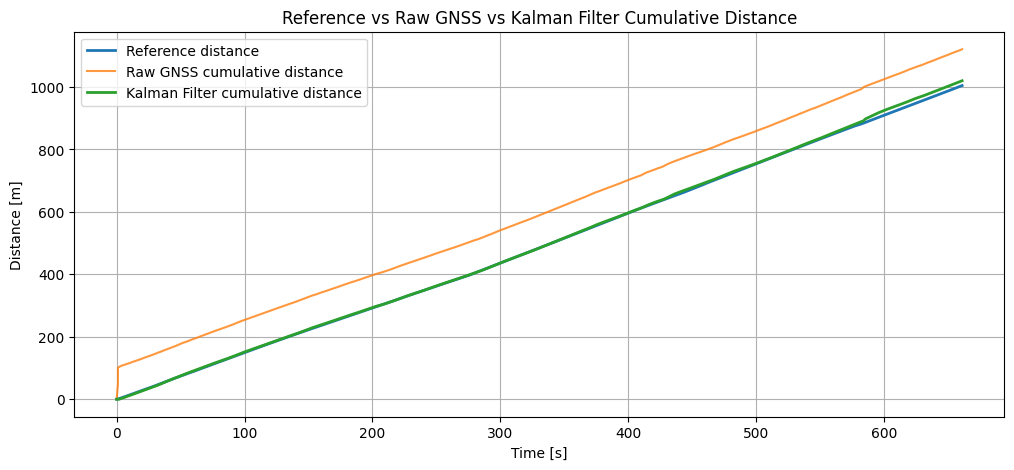

In [93]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_position_prepared["time_sec"],
    df_position_prepared["ref_dist_at_gnss_time"],
    label="Reference distance",
    linewidth=2
)

plt.plot(
    df_position_prepared["time_sec"],
    df_position_prepared["gnss_cumulative_distance"],
    label="Raw GNSS cumulative distance",
    alpha=0.8
)

plt.plot(
    df_kf["time_sec"],
    df_kf["kf_cumulative_distance"],
    label="Kalman Filter cumulative distance",
    linewidth=2
)

plt.xlabel("Time [s]")
plt.ylabel("Distance [m]")
plt.title("Reference vs Raw GNSS vs Kalman Filter Cumulative Distance")
plt.grid(True)
plt.legend()
plt.show()

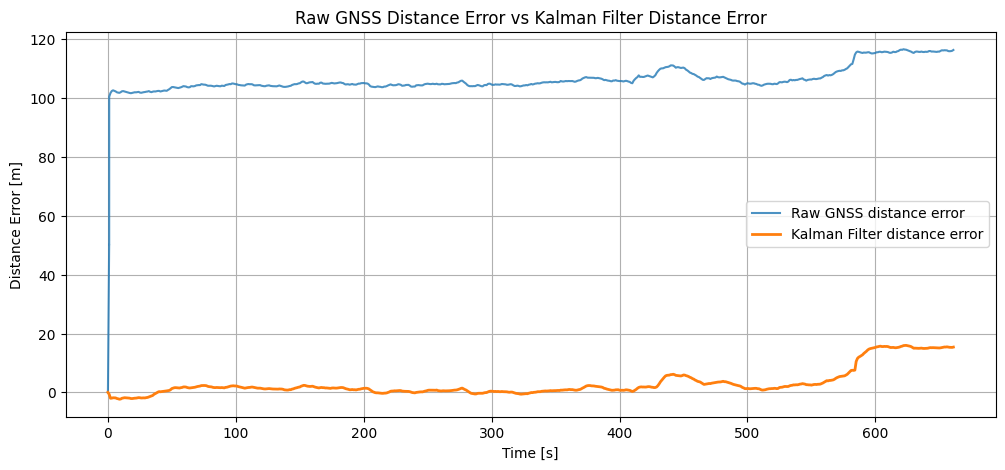

In [94]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_position_prepared["time_sec"],
    df_position_prepared["gnss_dist_error"],
    label="Raw GNSS distance error",
    alpha=0.8
)

plt.plot(
    df_kf["time_sec"],
    df_kf["kf_dist_error"],
    label="Kalman Filter distance error",
    linewidth=2
)

plt.xlabel("Time [s]")
plt.ylabel("Distance Error [m]")
plt.title("Raw GNSS Distance Error vs Kalman Filter Distance Error")
plt.grid(True)
plt.legend()
plt.show()

In [95]:
metrics = pd.DataFrame([
    {
        "method": "Raw GNSS",
        "final_distance_m": df_position_prepared["gnss_cumulative_distance"].iloc[-1],
        "final_distance_error_m": df_position_prepared["gnss_dist_error"].iloc[-1],
        "mean_abs_error_m": df_position_prepared["gnss_dist_error"].abs().mean(),
        "max_abs_error_m": df_position_prepared["gnss_dist_error"].abs().max(),
    },
    {
        "method": "Kalman Filter",
        "final_distance_m": df_kf["kf_cumulative_distance"].iloc[-1],
        "final_distance_error_m": df_kf["kf_dist_error"].iloc[-1],
        "mean_abs_error_m": df_kf["kf_dist_error"].abs().mean(),
        "max_abs_error_m": df_kf["kf_dist_error"].abs().max(),
    }
])

metrics

,method,final_distance_m,final_distance_error_m,mean_abs_error_m,max_abs_error_m
0,Raw GNSS,1121.112883,116.376365,106.059702,116.63316
1,Kalman Filter,1020.122616,15.386098,3.230264,15.97486


In [ ]:

# Final Metrics Table: Raw GNSS vs Kalman Filter

# Signed errors
df_position_prepared["gnss_dist_error_signed"] = (
    df_position_prepared["gnss_cumulative_distance"]
    - df_position_prepared["ref_dist_at_gnss_time"]
)

df_kf["kf_dist_error_signed"] = (
    df_kf["kf_cumulative_distance"]
    - df_kf["ref_dist_at_kf_time"]
)

# Absolute errors
df_position_prepared["gnss_dist_error_abs"] = (
    df_position_prepared["gnss_dist_error_signed"].abs()
)

df_kf["kf_dist_error_abs"] = (
    df_kf["kf_dist_error_signed"].abs()
)

# Metrics table
metrics_table = pd.DataFrame([
    {
        "Method": "Raw GNSS",
        "Final Distance [m]": df_position_prepared["gnss_cumulative_distance"].iloc[-1],
        "Reference Final Distance [m]": df_position_prepared["ref_dist_at_gnss_time"].iloc[-1],
        "Final Signed Error [m]": df_position_prepared["gnss_dist_error_signed"].iloc[-1],
        "Final Absolute Error [m]": df_position_prepared["gnss_dist_error_abs"].iloc[-1],
        "Mean Absolute Error [m]": df_position_prepared["gnss_dist_error_abs"].mean(),
        "Max Absolute Error [m]": df_position_prepared["gnss_dist_error_abs"].max(),
        "GNSS Updates Used": df_position_prepared["valid_gnss_updates"].sum(),
        "GNSS Updates Skipped": (df_position_prepared["valid_gnss_updates"] == 0).sum(),
    },
    {
        "Method": "Kalman Filter",
        "Final Distance [m]": df_kf["kf_cumulative_distance"].iloc[-1],
        "Reference Final Distance [m]": df_kf["ref_dist_at_kf_time"].iloc[-1],
        "Final Signed Error [m]": df_kf["kf_dist_error_signed"].iloc[-1],
        "Final Absolute Error [m]": df_kf["kf_dist_error_abs"].iloc[-1],
        "Mean Absolute Error [m]": df_kf["kf_dist_error_abs"].mean(),
        "Max Absolute Error [m]": df_kf["kf_dist_error_abs"].max(),
        "GNSS Updates Used": df_kf["used_gnss_update"].sum(),
        "GNSS Updates Skipped": (df_kf["used_gnss_update"] == 0).sum(),
    }
   
])

metrics_table.round(3)

,Method,Final Distance [m],Reference Final Distance [m],Final Signed Error [m],Final Absolute Error [m],Mean Absolute Error [m],Max Absolute Error [m],GNSS Updates Used,GNSS Updates Skipped
0,Raw GNSS,1121.113,1004.737,116.376,116.376,106.06,116.633,658,8
1,Kalman Filter,1020.123,1004.737,15.386,15.386,3.23,15.975,658,8


Final Summary

This notebook builds a preprocessing and quality-control pipeline for smartphone GNSS/IMU walking data. First, tracks with GNSS, IMU, and continuous reference distance were selected. Track 14_3 was chosen as a clean baseline because its app-measured distance was close to the reference distance and sensor gaps were low.

The raw GNSS trajectory showed early position jumps that inflated cumulative distance compared with the reference distance. GNSS outliers were detected using step distance, computed speed, GNSS-reported speed, and confidence interval. Instead of deleting all suspicious data, unreliable GNSS measurements were flagged so that they could be skipped during filtering.

The IMU signal showed useful high-frequency walking dynamics but was affected by phone orientation, hand movement, noise, and timing gaps. IMU suspicious points were therefore treated as reliability indicators rather than removed.

Finally, an initial Kalman-filter-based trajectory prototype was implemented using a constant-velocity prediction model and valid GNSS position updates. Flagged GNSS outliers were skipped during correction. This demonstrates an EKF-ready pipeline that can later be extended using IMU acceleration, orientation correction, bias estimation, and adaptive noise models.